# 2.1. Diseño e implementación de una red de aprendizaje profundo

## Propósito de la actividad

Aplicar los conocimientos **teóricos y prácticos** adquiridos durante la unidad mediante el **diseño e implementación de una red de aprendizaje profundo** orientada a la **clasificación y detección** de una característica o parámetro dentro de un área de interés.

## Instrucciones

A partir de los conceptos teóricos y prácticos abordados durante la unidad, selecciona un **problema relacionado con tu área de interés** que pueda ser atendido mediante técnicas de aprendizaje profundo.

Diseña y desarrolla una **red neuronal de aprendizaje profundo** capaz de realizar una **tarea de clasificación** para detectar o identificar una característica, condición o parámetro previamente definido.

El trabajo deberá incluir tanto el **diseño conceptual** de la red como su **implementación mediante código**, explicando de manera clara y detallada cada una de las etapas involucradas en el desarrollo del modelo.

### En tu propuesta deberás:

1. **Definir el problema** que se pretende resolver y explicar su relevancia dentro del área seleccionada.
2. **Describir los datos** que serán utilizados, indicando su origen, características y, en su caso, el proceso de preparación o preprocesamiento.
3. **Diseñar la arquitectura de la red**, representando mediante un esquema o diagrama sus principales componentes y la relación entre ellos.
4. **Implementar la red mediante código**, documentando las etapas principales del proceso.
5. **Explicar la función de los principales componentes** de la red, así como los parámetros y configuraciones utilizados.
6. **Entrenar y evaluar el modelo**, presentando los resultados obtenidos mediante los indicadores o métricas pertinentes.
7. **Analizar los resultados** y señalar fortalezas, limitaciones y posibles mejoras de la propuesta.
8. **Justificar la pertinencia** de utilizar aprendizaje profundo para resolver el problema planteado y explicar por qué la arquitectura seleccionada resulta adecuada para la tarea de clasificación.

## Requisitos de la actividad

Para el desarrollo de la actividad podrás utilizar las siguientes herramientas:

- **PowerPoint** u otro software para elaborar el diseño, esquema o diagrama de la arquitectura de la red.
- **Google Colab, Visual Studio Code y/o RStudio** para la implementación y ejecución del código.
- **Código fuente** de la red desarrollada, debidamente organizado y comentado.
- **Datos o conjunto de datos** utilizados para el entrenamiento y evaluación, indicando su fuente.
- **Evidencias** de la ejecución y de los resultados obtenidos.

## Producto final

Entrega un documento que integre:

- [ ] Descripción y justificación del problema.
- [ ] Diseño o diagrama de la arquitectura de la red.
- [ ] Explicación de las etapas de desarrollo.
- [ ] Código de implementación.
- [ ] Resultados del entrenamiento y evaluación.
- [ ] Análisis de resultados.
- [ ] Conclusiones y posibles mejoras.

> **Nota:** El trabajo deberá demostrar la comprensión de los fundamentos del aprendizaje profundo y su aplicación práctica a un problema de clasificación, justificando las decisiones tomadas durante el diseño e implementación del modelo.

**Alumno:** Marco Sebastián Hernández Parada

**Materia:** Aprendizaje profundo, Unidad 2

**Práctica:** 2.1 Diseño e implementación de una red de aprendizaje profundo

**Tema:** Clasificación de especies animales en fotografías con una red neuronal convolucional (CNN) diseñada desde cero, comparada con transfer learning

## Índice

1. Entorno de trabajo: versión de Python y librerías
2. Definición del problema y relevancia
3. Datos: origen, características y obtención
4. Preprocesamiento
5. Diseño de la arquitectura de la red
6. Función de los componentes y configuración
7. Entrenamiento (reanudable)
8. Evaluación de la CNN
9. Comparación: transfer learning con EfficientNetB0
10. Análisis de resultados
11. Justificación del uso de aprendizaje profundo y de la arquitectura
12. Conclusiones y posibles mejoras
13. Referencias

## 1. Entorno de trabajo: versión de Python y librerías

La práctica se desarrolló y ejecutó con el siguiente entorno:

| Componente | Versión utilizada | Uso en la práctica |
|---|---|---|
| **Python** | 3.13.7 | Lenguaje base |
| **TensorFlow** | 2.21.0 | Lectura de imágenes (`tf.data`), entrenamiento y ejecución de la red |
| **Keras** | 3.14.0 | Definición de la arquitectura (capas, optimizador, callbacks) |
| **kagglehub** | 1.0.2 | Descarga automática del conjunto de datos desde Kaggle |
| **NumPy** | 2.3.3 | Operaciones numéricas con arreglos |
| **pandas** | 2.3.3 | Tablas de conteos y métricas |
| **Matplotlib** | 3.10.7 | Gráficas, diagrama de la arquitectura y visualización de imágenes |
| **seaborn** | 0.13.2 | Matriz de confusión |
| **scikit-learn** | 1.7.2 | División estratificada de los datos, pesos por clase y métricas |
| **Pillow** | 11.3.0 | Lectura de los tamaños originales de las imágenes |
| **EfficientNetB0** (pesos ImageNet) | Keras Applications | Red preentrenada usada solo en la sección 9, como comparación. Keras descarga los pesos (~16 MB) la primera vez |

> **Nota sobre el hardware:** desde la versión 2.11, TensorFlow ya no usa la GPU en Windows nativo (solo mediante WSL2). Por eso todo el entrenamiento se hizo **en CPU**. Esto influyó en decisiones como la resolución de entrada (128 × 128) y el tamaño de la red.

La siguiente celda importa las librerías e imprime las versiones con las que se ejecutó el cuaderno.

In [1]:
# Si falta alguna dependencia, descomenta la siguiente línea y ejecútala una vez:
# %pip install tensorflow kagglehub numpy pandas matplotlib seaborn scikit-learn pillow

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # Oculta los mensajes informativos de TensorFlow

import sys        # Información del intérprete de Python
import platform   # Información del sistema operativo
import time       # Medición de tiempos
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import PIL
from PIL import Image
import kagglehub
import tensorflow as tf
import keras
tf.get_logger().setLevel("ERROR")          # Oculta avisos de TensorFlow que no afectan el resultado
from keras import layers

print(f"Python        : {sys.version.split()[0]}")
print(f"Sistema       : {platform.system()} {platform.release()} ({platform.machine()})")
print(f"TensorFlow    : {tf.__version__}")
print(f"Keras         : {keras.__version__}")
print(f"kagglehub     : {kagglehub.__version__}")
print(f"NumPy         : {np.__version__}")
print(f"pandas        : {pd.__version__}")
print(f"Matplotlib    : {matplotlib.__version__}")
print(f"seaborn       : {sns.__version__}")
print(f"scikit-learn  : {sklearn.__version__}")
print(f"Pillow        : {PIL.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU') or 'No (se entrena en CPU)'}")

Python        : 3.13.7
Sistema       : Windows 10 (AMD64)
TensorFlow    : 2.21.0
Keras         : 3.14.0
kagglehub     : 1.0.2
NumPy         : 2.3.3
pandas        : 2.3.3
Matplotlib    : 3.10.7
seaborn       : 0.13.2
scikit-learn  : 1.7.2
Pillow        : 11.3.0
GPU disponible: No (se entrena en CPU)


In [2]:
from sklearn.model_selection import train_test_split          # División estratificada
from sklearn.utils.class_weight import compute_class_weight   # Pesos para compensar el desbalance
from sklearn.metrics import classification_report, confusion_matrix

# Semilla global: fija Python, NumPy y TensorFlow para que los resultados sean reproducibles
SEMILLA = 42
keras.utils.set_random_seed(SEMILLA)

# Hiperparámetros generales de la práctica
TAM_IMAGEN = 128        # Las imágenes se redimensionan a 128 × 128 píxeles
TAM_LOTE = 32           # Imágenes por lote (batch)
EPOCAS_MAX = 40         # Máximo de épocas (la parada temprana puede terminar antes)

plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 11})

## 2. Definición del problema y relevancia

### Problema

Dada una **fotografía de un animal**, identificar automáticamente **a cuál de 10 especies pertenece**: perro, caballo, elefante, mariposa, gallina, gato, vaca, oveja, araña o ardilla.

Es un problema de **clasificación multiclase** de imágenes. La entrada es una matriz de píxeles RGB y la salida es una distribución de probabilidad sobre las 10 clases. Se predice la clase con la probabilidad más alta.

### Relevancia en el área

La identificación automática de animales en imágenes es una tarea central en la **ecología computacional** y la **conservación de la biodiversidad**:

- **Fototrampeo:** las cámaras trampa que se instalan en reservas generan millones de fotografías. Revisarlas a mano puede tomar meses; un clasificador automático filtra las imágenes vacías y etiqueta las especies en minutos (Norouzzadeh et al., 2018).
- **Ciencia ciudadana:** aplicaciones como iNaturalist sugieren la especie a partir de la foto que toma un usuario.
- **Ganadería y agricultura de precisión:** conteo y monitoreo de animales de granja (vacas, ovejas, gallinas), que son 3 de las clases de este problema.
- **Seguridad y control de plagas:** detectar arañas o fauna silvestre en zonas urbanas o de cultivo.

### Por qué es un problema difícil

- Las fotografías **no están controladas**: cambian el fondo, la iluminación, la pose, la escala y el ángulo, y a veces aparecen varios animales o personas.
- Hay especies **visualmente parecidas** (vaca/caballo, oveja/perro de pelo claro, gato/perro).
- Dentro de una misma clase la variación es enorme: "perro" incluye desde un chihuahua hasta un gran danés.

Escribir reglas a mano ("si tiene cuatro patas y orejas puntiagudas...") es imposible. Por eso se usa **aprendizaje profundo**: la red aprende directamente de los píxeles qué características distinguen a cada especie.

## 3. Datos: origen, características y obtención

### 3.1 Origen

Se utiliza el conjunto de datos **Animals-10**, publicado en Kaggle por Alessio Corrado:

- Enlace: <https://www.kaggle.com/datasets/alessiocorrado99/animals10>
- Contenido: **26,179 fotografías** a color de **10 especies**, obtenidas de Google Images y revisadas manualmente por el autor.
- Las carpetas vienen nombradas **en italiano** (`cane` = perro, `gatto` = gato, etc.). Más adelante se traducen al español.
- Las imágenes tienen tamaños distintos (la mayoría alrededor de 300 × 225 píxeles) y formatos JPEG y PNG.

### 3.2 Cómo obtener el dataset

El dataset pesa aproximadamente **650 MB**, por lo que **no se incluye en el repositorio de GitHub**: la carpeta `dataset/` está listada en el archivo `.gitignore`. Hay dos formas de obtenerlo:

**Opción A, automática (recomendada).** La siguiente celda usa la librería `kagglehub` para descargar el dataset y guardarlo en la carpeta `dataset/`, junto a este cuaderno. Para datasets públicos no se necesita cuenta de Kaggle. Si la carpeta ya existe, la descarga se omite.

```bash
pip install kagglehub
```

**Opción B, manual.**

1. Entrar a <https://www.kaggle.com/datasets/alessiocorrado99/animals10> e iniciar sesión.
2. Presionar **Download** para bajar el archivo ZIP.
3. Descomprimirlo en una carpeta `dataset/` junto a este cuaderno, de modo que quede la ruta `dataset/raw-img/<especie>/<imagen>`.

Estructura esperada:

```
Practica 2.1/
    Diseño e implementación de una red de aprendizaje profundo.ipynb
    dataset/                  (ignorada por git)
        raw-img/
            cane/
            cavallo/
            ...
    modelos/                  (ignorada por git, se crea al entrenar)
```

In [3]:
RUTA_DATASET = Path("dataset")                # Carpeta local (incluida en .gitignore)
RUTA_IMAGENES = RUTA_DATASET / "raw-img"      # Aquí quedan las 10 carpetas de especies

if RUTA_IMAGENES.exists() and any(RUTA_IMAGENES.iterdir()):
    print(f"El dataset ya existe en '{RUTA_IMAGENES}'. Se omite la descarga.")
else:
    print("Descargando Animals-10 desde Kaggle (~590 MB comprimido)...")
    ruta = kagglehub.dataset_download("alessiocorrado99/animals10", output_dir=str(RUTA_DATASET))
    print(f"Dataset descargado en: {ruta}")

print("Carpetas encontradas:", sorted(p.name for p in RUTA_IMAGENES.iterdir()))

El dataset ya existe en 'dataset\raw-img'. Se omite la descarga.
Carpetas encontradas: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


### 3.3 Exploración del conjunto de datos

Primero se traducen los nombres de las carpetas y se arma una lista con la ruta y la etiqueta de cada imagen.

In [4]:
# Traducción de las carpetas (italiano) a español
TRADUCCION = {
    "cane": "perro", "cavallo": "caballo", "elefante": "elefante", "farfalla": "mariposa",
    "gallina": "gallina", "gatto": "gato", "mucca": "vaca", "pecora": "oveja",
    "ragno": "araña", "scoiattolo": "ardilla",
}

CARPETAS = sorted(TRADUCCION)                          # Orden fijo (alfabético en italiano)
CLASES = [TRADUCCION[c] for c in CARPETAS]             # Nombre en español de cada índice
NUM_CLASES = len(CLASES)
EXTENSIONES = {".jpg", ".jpeg", ".png"}

rutas, etiquetas = [], []
for indice, carpeta in enumerate(CARPETAS):
    for archivo in sorted((RUTA_IMAGENES / carpeta).iterdir()):
        if archivo.suffix.lower() in EXTENSIONES:
            rutas.append(str(archivo))
            etiquetas.append(indice)

rutas = np.array(rutas)
etiquetas = np.array(etiquetas)

conteo = (pd.Series(etiquetas).map(dict(enumerate(CLASES))).value_counts()
          .rename_axis("Especie").reset_index(name="Imágenes"))
conteo["Porcentaje"] = (100 * conteo["Imágenes"] / conteo["Imágenes"].sum()).round(1)

print(f"Total de imágenes: {len(rutas):,}")
print(f"Clases ({NUM_CLASES}): {CLASES}\n")
print(conteo.to_string(index=False))

Total de imágenes: 26,179
Clases (10): ['perro', 'caballo', 'elefante', 'mariposa', 'gallina', 'gato', 'vaca', 'oveja', 'araña', 'ardilla']

 Especie  Imágenes  Porcentaje
   perro      4863        18.6
   araña      4821        18.4
 gallina      3098        11.8
 caballo      2623        10.0
mariposa      2112         8.1
    vaca      1866         7.1
 ardilla      1862         7.1
   oveja      1820         7.0
    gato      1668         6.4
elefante      1446         5.5


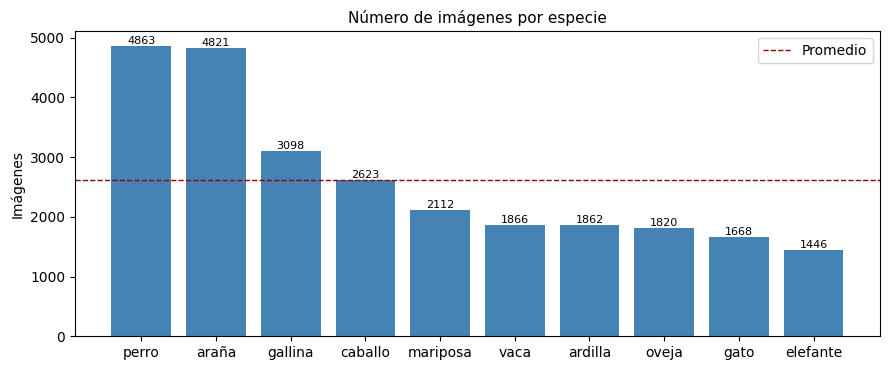

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.8))
barras = ax.bar(conteo["Especie"], conteo["Imágenes"], color="steelblue")
ax.bar_label(barras, fontsize=8)
ax.axhline(conteo["Imágenes"].mean(), color="darkred", ls="--", lw=1, label="Promedio")
ax.set_title("Número de imágenes por especie")
ax.set_ylabel("Imágenes")
ax.legend()
plt.tight_layout()
plt.show()

El conjunto está **desbalanceado**: hay más de 4,800 imágenes de perros y arañas, y solo unas 1,450 de elefantes (una proporción aproximada de 3.4 a 1). Si no se corrige, la red tiende a favorecer las clases mayoritarias. En el preprocesamiento esto se compensa con **pesos por clase**.

A continuación se muestran ejemplos de cada especie y la distribución de tamaños originales.

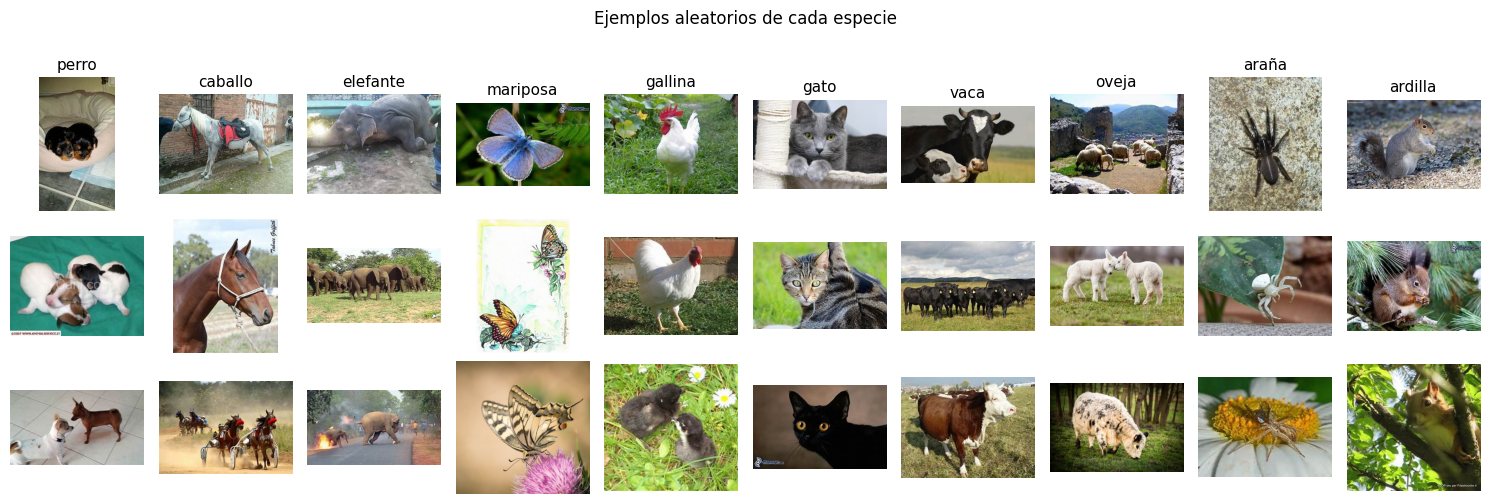

In [6]:
rng = np.random.default_rng(SEMILLA)
fig, ejes = plt.subplots(3, NUM_CLASES, figsize=(15, 5))
for c in range(NUM_CLASES):
    muestras = rng.choice(rutas[etiquetas == c], size=3, replace=False)
    for f, ruta in enumerate(muestras):
        ejes[f, c].imshow(Image.open(ruta).convert("RGB"))
        ejes[f, c].axis("off")
    ejes[0, c].set_title(CLASES[c])
plt.suptitle("Ejemplos aleatorios de cada especie", y=1.0)
plt.tight_layout()
plt.show()

Ancho: mediana 300 px, mínimo 60, máximo 6720
Alto : mediana 225 px, mínimo 57, máximo 6000


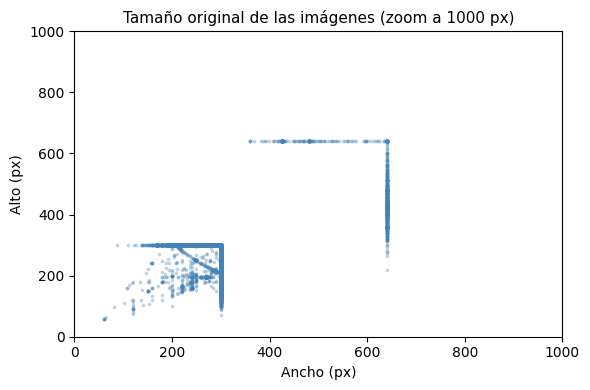

In [7]:
# Tamaños originales (ancho, alto). Image.open solo lee el encabezado, no la imagen completa.
tamanos = np.array([Image.open(r).size for r in rutas])
anchos, altos = tamanos[:, 0], tamanos[:, 1]

print(f"Ancho: mediana {np.median(anchos):.0f} px, mínimo {anchos.min()}, máximo {anchos.max()}")
print(f"Alto : mediana {np.median(altos):.0f} px, mínimo {altos.min()}, máximo {altos.max()}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(anchos, altos, s=3, alpha=0.25, color="steelblue")
ax.set_xlim(0, 1000)
ax.set_ylim(0, 1000)
ax.set_xlabel("Ancho (px)")
ax.set_ylabel("Alto (px)")
ax.set_title("Tamaño original de las imágenes (zoom a 1000 px)")
plt.tight_layout()
plt.show()

La mayoría de las imágenes mide alrededor de 300 × 225 píxeles, aunque hay algunas muy grandes (más de 6000 px). Como la red necesita una entrada de tamaño fijo, **todas se redimensionan a 128 × 128**. Se eligió ese tamaño porque conserva la forma general del animal y permite entrenar en CPU en un tiempo razonable.

## 4. Preprocesamiento

### 4.1 División en entrenamiento, validación y prueba

| Subconjunto | Proporción | Uso |
|---|---|---|
| **Entrenamiento** | 70 % | La red ajusta sus pesos con estas imágenes |
| **Validación** | 15 % | Se evalúa al final de cada época para detectar sobreajuste, ajustar la tasa de aprendizaje y decidir cuándo detener el entrenamiento |
| **Prueba** | 15 % | Solo se usa **una vez, al final**, para medir el desempeño real con imágenes que la red nunca vio |

La división es **estratificada** (`stratify`), de modo que los tres subconjuntos conservan la misma proporción de cada especie.

In [8]:
# Primero se separa 70 % de entrenamiento y 30 % restante; luego ese 30 % se parte a la mitad
rutas_ent, rutas_tmp, y_ent, y_tmp = train_test_split(
    rutas, etiquetas, test_size=0.30, stratify=etiquetas, random_state=SEMILLA)
rutas_val, rutas_pru, y_val, y_pru = train_test_split(
    rutas_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEMILLA)

print(f"Entrenamiento: {len(rutas_ent):>6,} imágenes")
print(f"Validación   : {len(rutas_val):>6,} imágenes")
print(f"Prueba       : {len(rutas_pru):>6,} imágenes")

Entrenamiento: 18,325 imágenes
Validación   :  3,927 imágenes
Prueba       :  3,927 imágenes


### 4.2 Pipeline de lectura con `tf.data`

Cargar 26,000 imágenes a memoria como `float32` ocuparía casi 5 GB. En su lugar se usa `tf.data`, que lee y prepara las imágenes por lotes:

1. **Leer y decodificar** el archivo (JPEG o PNG) a un tensor RGB de 3 canales. Las imágenes PNG con canal alfa o en escala de grises también se convierten a RGB.
2. **Redimensionar** a 128 × 128 con suavizado (*antialias*) para no generar artefactos al reducir.
3. Guardar como `uint8` (0 a 255) y **cachear en disco** durante la primera época, en `dataset/cache/` (~1.3 GB, ignorada por git). Así las siguientes épocas, y las siguientes ejecuciones del cuaderno, no vuelven a decodificar los archivos. Se usa el disco y no la memoria RAM porque, junto con el entrenamiento, la caché en RAM llegó a agotar la memoria de la computadora.
4. **Barajar** (solo en entrenamiento), agrupar en **lotes de 32** y usar `prefetch` para preparar el siguiente lote mientras la red procesa el actual.

La **normalización** (dividir entre 255) y el **aumento de datos** no se hacen aquí sino **dentro del modelo**, como sus primeras capas. Así el modelo guardado recibe imágenes crudas y aplica exactamente el mismo preprocesamiento al usarse después.

In [9]:
AUTOTUNE = tf.data.AUTOTUNE


def cargar_imagen(ruta, etiqueta):
    # Lee el archivo, lo decodifica a RGB y lo redimensiona a TAM_IMAGEN x TAM_IMAGEN
    imagen = tf.io.decode_image(tf.io.read_file(ruta), channels=3, expand_animations=False)
    imagen = tf.image.resize(imagen, (TAM_IMAGEN, TAM_IMAGEN), antialias=True)
    imagen = tf.cast(tf.clip_by_value(tf.round(imagen), 0, 255), tf.uint8)   # uint8 ocupa 4 veces menos que float32
    return imagen, etiqueta


RUTA_CACHE = RUTA_DATASET / "cache"      # Dentro de dataset/, así que también la ignora git
RUTA_CACHE.mkdir(exist_ok=True)


def crear_dataset(rutas, etiquetas, nombre, entrenamiento=False):
    # Si una ejecución anterior se interrumpió mientras escribía la caché, queda un .lockfile y la caché
    # está incompleta: se borra para que se vuelva a crear. (La caché depende de la división de los datos;
    # si se cambia SEMILLA o TAM_IMAGEN hay que borrar la carpeta dataset/cache.)
    if any(RUTA_CACHE.glob(f"{nombre}*.lockfile")):
        for archivo in RUTA_CACHE.glob(f"{nombre}*"):
            archivo.unlink()
    ds = tf.data.Dataset.from_tensor_slices((rutas, etiquetas))
    ds = ds.map(cargar_imagen, num_parallel_calls=AUTOTUNE).cache(str(RUTA_CACHE / nombre))
    if entrenamiento:
        ds = ds.shuffle(4000, seed=SEMILLA, reshuffle_each_iteration=True)
    ds = ds.batch(TAM_LOTE)
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y))   # La red trabaja en float32
    return ds.prefetch(AUTOTUNE)


ds_ent = crear_dataset(rutas_ent, y_ent, f"entrenamiento_{TAM_IMAGEN}px", entrenamiento=True)
ds_val = crear_dataset(rutas_val, y_val, f"validacion_{TAM_IMAGEN}px")
ds_pru = crear_dataset(rutas_pru, y_pru, f"prueba_{TAM_IMAGEN}px")

lote_x, lote_y = next(iter(ds_val))
print("Forma de un lote de imágenes:", lote_x.shape, lote_x.dtype)
print("Forma de un lote de etiquetas:", lote_y.shape, lote_y.dtype)
print(f"Rango de píxeles: [{lote_x.numpy().min():.0f}, {lote_x.numpy().max():.0f}]")

Forma de un lote de imágenes: (32, 128, 128, 3) <dtype: 'float32'>
Forma de un lote de etiquetas: (32,) <dtype: 'int64'>
Rango de píxeles: [0, 255]


### 4.3 Pesos por clase (suavizados)

Para compensar el desbalance, cada clase recibe un peso mayor cuanto menos imágenes tiene. El peso "balanceado" clásico es:

$$
w_c^{bal} = \frac{N}{K \cdot n_c}
$$

donde $N$ es el total de imágenes de entrenamiento, $K = 10$ el número de clases y $n_c$ las imágenes de la clase $c$. Durante el entrenamiento, el error de cada imagen se multiplica por el peso de su clase.

En la **primera versión** del modelo se usó $w_c^{bal}$ directamente y la red terminó **sobrecompensando**: predecía de más las clases minoritarias (el elefante tenía 88 % de sensibilidad pero solo 33 % de precisión) y de menos las mayoritarias (el perro solo 31 % de sensibilidad). Por eso aquí se usa una versión **suavizada** con raíz cuadrada:

$$
w_c = \sqrt{w_c^{bal}}
$$

que sigue dando más peso a las clases pequeñas, pero con una diferencia menos extrema (de ~3.4 a 1 pasa a ~1.8 a 1).

In [10]:
pesos_balanceados = compute_class_weight("balanced", classes=np.arange(NUM_CLASES), y=y_ent)
pesos = np.sqrt(pesos_balanceados)
PESOS_CLASE = dict(enumerate(pesos))

print(pd.DataFrame({"Especie": CLASES, "Imágenes (ent.)": np.bincount(y_ent),
                    "Peso balanceado": pesos_balanceados.round(3), "Peso usado (raíz)": pesos.round(3)})
      .to_string(index=False))

 Especie  Imágenes (ent.)  Peso balanceado  Peso usado (raíz)
   perro             3404            0.538              0.734
 caballo             1836            0.998              0.999
elefante             1012            1.811              1.346
mariposa             1478            1.240              1.113
 gallina             2169            0.845              0.919
    gato             1168            1.569              1.253
    vaca             1306            1.403              1.185
   oveja             1274            1.438              1.199
   araña             3375            0.543              0.737
 ardilla             1303            1.406              1.186


### 4.4 Aumento de datos (*data augmentation*)

El aumento de datos genera, en cada época, **variaciones aleatorias** de las imágenes de entrenamiento. Un gato sigue siendo gato aunque la foto esté volteada, un poco girada o más cerca, así que la red aprende a no depender de esos detalles y **se reduce el sobreajuste**. Solo se aplica durante el entrenamiento; en validación, prueba y predicción estas capas no hacen nada.

Se usan transformaciones **moderadas**: volteo horizontal, rotación de hasta ±18° y zoom de hasta 10 %. En la primera versión también había desplazamientos y cambios de contraste más fuertes. Junto con mucho dropout, eso hizo que la red **no alcanzara a ajustar ni los datos de entrenamiento** (67 % de exactitud en entrenamiento). Como el modelo tenía subajuste y no sobreajuste, se redujo la regularización.

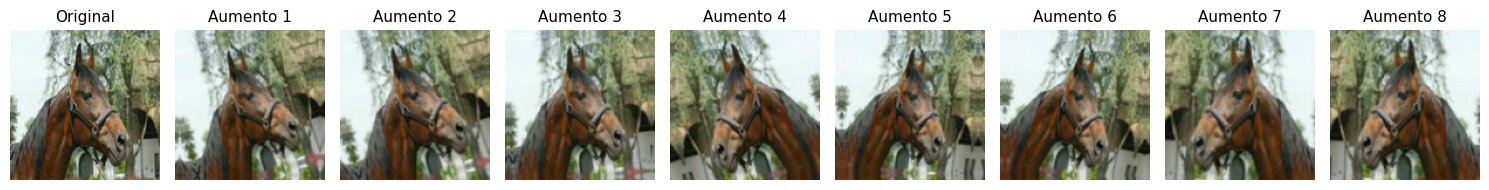

In [11]:
aumento_datos = keras.Sequential([
    layers.RandomFlip("horizontal"),              # Espejo izquierda/derecha
    layers.RandomRotation(0.05),                  # Rotación de hasta ±5 % de vuelta (~±18°)
    layers.RandomZoom(0.1),                       # Acercamiento/alejamiento de hasta 10 %
], name="aumento_datos")

# Visualización: la misma imagen con 8 aumentos aleatorios distintos
imagen_ej = lote_x[0:1]
fig, ejes = plt.subplots(1, 9, figsize=(15, 2.2))
ejes[0].imshow(imagen_ej[0].numpy().astype("uint8"))
ejes[0].set_title("Original")
for i in range(1, 9):
    aumentada = aumento_datos(imagen_ej, training=True)
    ejes[i].imshow(np.clip(aumentada[0].numpy(), 0, 255).astype("uint8"))
    ejes[i].set_title(f"Aumento {i}")
for ax in ejes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Diseño de la arquitectura de la red

Se diseñó una **red neuronal convolucional (CNN)** desde cero, sin pesos preentrenados. Tiene tres partes:

1. **Preprocesamiento dentro del modelo:** aumento de datos y normalización de los píxeles a [0, 1].
2. **Extractor de características:** 5 bloques convolucionales. Cada convolución va seguida de `BatchNormalization → ReLU`, y cada bloque termina con `MaxPooling (2×2)`. Los bloques 3 y 4 tienen **dos convoluciones seguidas**. El número de filtros se duplica en cada bloque (32 → 64 → 128 → 256 → 512) mientras la resolución se reduce a la mitad (128 → 64 → 32 → 16 → 8 → 4).
3. **Clasificador:** `GlobalAveragePooling → Dense(256, ReLU) → Dropout(0.3) → Dense(10, softmax)`.

La idea de diseño es la **jerarquía de características**: los primeros bloques ven regiones pequeñas y detectan bordes y colores; los últimos combinan esas piezas en patrones más grandes (texturas de pelo o plumas, patas, orejas, alas) que distinguen a cada especie.

### 5.1 Proceso de diseño: de la versión 1 a la versión 2

La arquitectura final es la **segunda iteración**. La primera versión (4 bloques de una sola convolución, 32 a 256 filtros, ~424 mil parámetros, dropout de 0.4 y 0.3, aumento de datos fuerte y Adam con `ReduceLROnPlateau`) se entrenó 35 épocas y obtuvo:

| Métrica (versión 1) | Valor |
|---|---|
| Exactitud en entrenamiento (última época) | 67.3 % |
| Exactitud en validación (mejor época) | 59.2 % |
| Exactitud en prueba | 59.5 % |
| F1 macro en prueba | 0.581 |

El diagnóstico fue **subajuste**: la red no alcanzaba a aprender ni siquiera los datos de entrenamiento. Además, la exactitud de validación saltaba entre 30 % y 58 % de una época a otra. Los cambios de la versión 2 atacan esas causas:

| Problema observado | Cambio en la versión 2 |
|---|---|
| Poca capacidad (67 % en entrenamiento) | Dos convoluciones en los bloques 3 y 4, un quinto bloque de 512 filtros y capa densa de 256. Pasa de 0.42 a 2.4 millones de parámetros |
| Demasiada regularización | Aumento de datos moderado y un solo dropout de 0.3 |
| Validación inestable | Tasa de aprendizaje con **calentamiento y decaimiento coseno**: pasos pequeños al final, cuando se afinan los pesos |
| Sobrecompensación del desbalance | Pesos por clase suavizados con raíz cuadrada |
| Optimizador sin regularización de pesos | **AdamW** (Adam con *weight decay* desacoplado) |

In [12]:
# Keras dibuja la tabla de model.summary() con caracteres de recuadro (Unicode U+2500 a U+257F) que la
# fuente del PDF no tiene. Se cambian por ASCII: horizontales -> "-", verticales -> "|", esquinas y cruces -> "+"
RECUADRO_A_ASCII = {c: "+" for c in range(0x2500, 0x2580)} | {0x2500: "-", 0x2501: "-", 0x2502: "|", 0x2503: "|"}


def imprimir_resumen(texto, line_break=None):
    print(texto.translate(RECUADRO_A_ASCII))


def bloque_conv(x, filtros, num_convs, nombre):
    # num_convs veces: Conv 3x3 -> BatchNorm -> ReLU; al final, MaxPooling 2x2
    for k in range(1, num_convs + 1):
        x = layers.Conv2D(filtros, 3, padding="same", use_bias=False, name=f"conv{nombre}_{k}")(x)  # BN ya aporta el sesgo
        x = layers.BatchNormalization(name=f"bn{nombre}_{k}")(x)
        x = layers.Activation("relu", name=f"relu{nombre}_{k}")(x)
    return layers.MaxPooling2D(2, name=f"pool{nombre}")(x)


def construir_cnn(num_clases=NUM_CLASES, tam=TAM_IMAGEN):
    entradas = keras.Input(shape=(tam, tam, 3), name="imagen")

    # Preprocesamiento dentro del modelo
    x = aumento_datos(entradas)                               # Solo activo durante el entrenamiento
    x = layers.Rescaling(1.0 / 255, name="normalizacion")(x)  # Píxeles de [0, 255] a [0, 1]

    # Extractor de características: (filtros, convoluciones por bloque)
    for b, (filtros, num_convs) in enumerate([(32, 1), (64, 1), (128, 2), (256, 2), (512, 1)], start=1):
        x = bloque_conv(x, filtros, num_convs, b)

    # Clasificador
    x = layers.GlobalAveragePooling2D(name="gap")(x)          # 4x4x512 -> vector de 512
    x = layers.Dense(256, activation="relu", name="densa")(x)
    x = layers.Dropout(0.3, name="dropout")(x)
    salidas = layers.Dense(num_clases, activation="softmax", name="salida")(x)

    return keras.Model(entradas, salidas, name="CNN_Animals10_v2")


modelo = construir_cnn()
modelo.summary(print_fn=imprimir_resumen)

Model: "CNN_Animals10_v2"
+---------------------------------+------------------------+---------------+
| Layer (type)                    | Output Shape           |       Param # |
+---------------------------------+------------------------+---------------+
| imagen (InputLayer)             | (None, 128, 128, 3)    |             0 |
+---------------------------------+------------------------+---------------+
| aumento_datos (Sequential)      | (None, 128, 128, 3)    |             0 |
+---------------------------------+------------------------+---------------+
| normalizacion (Rescaling)       | (None, 128, 128, 3)    |             0 |
+---------------------------------+------------------------+---------------+
| conv1_1 (Conv2D)                | (None, 128, 128, 32)   |           864 |
+---------------------------------+------------------------+---------------+
| bn1_1 (BatchNormalization)      | (None, 128, 128, 32)   |           128 |
+---------------------------------+---------------

### 5.2 Diagrama de la arquitectura

El diagrama muestra el flujo de una imagen por la red y la forma del tensor a la salida de cada etapa (alto × ancho × canales).

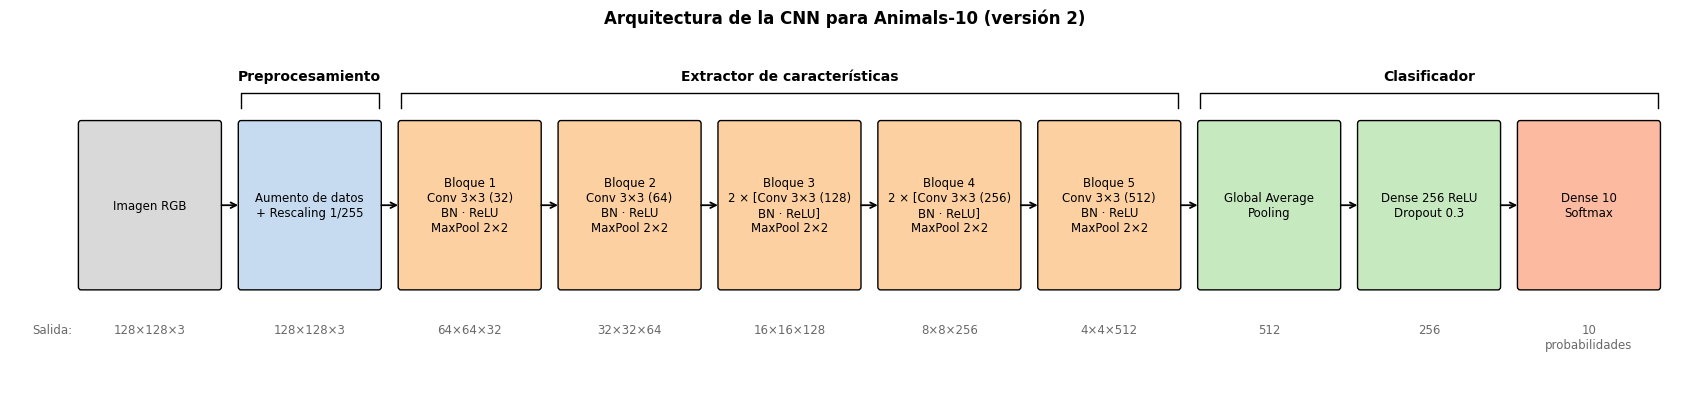

In [13]:
from matplotlib.patches import FancyBboxPatch

# (texto de la capa, forma de salida, color por tipo de capa)
COLOR = {"entrada": "#d9d9d9", "prep": "#c6dbef", "conv": "#fdd0a2", "clasif": "#c7e9c0", "salida": "#fcbba1"}
etapas = [
    ("Imagen RGB", "128×128×3", "entrada"),
    ("Aumento de datos\n+ Rescaling 1/255", "128×128×3", "prep"),
    ("Bloque 1\nConv 3×3 (32)\nBN · ReLU\nMaxPool 2×2", "64×64×32", "conv"),
    ("Bloque 2\nConv 3×3 (64)\nBN · ReLU\nMaxPool 2×2", "32×32×64", "conv"),
    ("Bloque 3\n2 × [Conv 3×3 (128)\nBN · ReLU]\nMaxPool 2×2", "16×16×128", "conv"),
    ("Bloque 4\n2 × [Conv 3×3 (256)\nBN · ReLU]\nMaxPool 2×2", "8×8×256", "conv"),
    ("Bloque 5\nConv 3×3 (512)\nBN · ReLU\nMaxPool 2×2", "4×4×512", "conv"),
    ("Global Average\nPooling", "512", "clasif"),
    ("Dense 256 ReLU\nDropout 0.3", "256", "clasif"),
    ("Dense 10\nSoftmax", "10\nprobabilidades", "salida"),
]

fig, ax = plt.subplots(figsize=(17, 4.2))
ancho, alto, sep = 1.55, 1.6, 0.25
for i, (texto, forma, tipo) in enumerate(etapas):
    x0 = i * (ancho + sep)
    ax.add_patch(FancyBboxPatch((x0, 0), ancho, alto, boxstyle="round,pad=0.03",
                                fc=COLOR[tipo], ec="black", lw=1))
    ax.text(x0 + ancho / 2, alto / 2, texto, ha="center", va="center", fontsize=8.5)
    ax.text(x0 + ancho / 2, -0.35, forma, ha="center", va="top", fontsize=8.5, color="dimgray")
    if i < len(etapas) - 1:
        ax.annotate("", xy=(x0 + ancho + sep, alto / 2), xytext=(x0 + ancho, alto / 2),
                    arrowprops=dict(arrowstyle="->", lw=1.3))

# Llaves que agrupan las tres partes de la red
grupos = [(1, 1, "Preprocesamiento"), (2, 6, "Extractor de características"), (7, 9, "Clasificador")]
for ini, fin, nombre in grupos:
    xa, xb = ini * (ancho + sep), fin * (ancho + sep) + ancho
    ax.plot([xa, xa, xb, xb], [alto + 0.15, alto + 0.3, alto + 0.3, alto + 0.15], color="black", lw=1)
    ax.text((xa + xb) / 2, alto + 0.4, nombre, ha="center", va="bottom", fontsize=10, weight="bold")

ax.text(-0.1, -0.35, "Salida:", ha="right", va="top", fontsize=8.5, color="dimgray")
ax.set_xlim(-0.8, len(etapas) * (ancho + sep))
ax.set_ylim(-1.1, alto + 0.9)
ax.axis("off")
ax.set_title("Arquitectura de la CNN para Animals-10 (versión 2)", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()

### 5.3 Cálculo de parámetros

Para una capa convolucional sin sesgo, los parámetros son $k \times k \times C_{entrada} \times C_{salida}$. Cada `BatchNormalization` agrega 4 por canal: $\gamma$ y $\beta$, que se entrenan, y la media y la varianza móviles, que no se entrenan. Una capa densa tiene $n_{entrada} \times n_{salida} + n_{salida}$.

| Capa | Cálculo | Parámetros |
|---|---|---|
| conv1_1 | 3·3·3·32 | 864 |
| conv2_1 | 3·3·32·64 | 18,432 |
| conv3_1 | 3·3·64·128 | 73,728 |
| conv3_2 | 3·3·128·128 | 147,456 |
| conv4_1 | 3·3·128·256 | 294,912 |
| conv4_2 | 3·3·256·256 | 589,824 |
| conv5_1 | 3·3·256·512 | 1,179,648 |
| BatchNormalization (7 capas) | 4·(32+64+128+128+256+256+512) | 5,504 |
| densa | 512·256 + 256 | 131,328 |
| salida | 256·10 + 10 | 2,570 |
| **Total** | | **2,444,266** |

Casi la mitad de los parámetros está en el bloque 5, pero ese bloque trabaja sobre un mapa de solo 8×8, así que su costo de cómputo es moderado. Gracias a `GlobalAveragePooling`, la capa densa recibe 512 valores. Con `Flatten` sobre el mapa de 4×4×512 recibiría 8,192 y tendría más de 2 millones de parámetros ella sola.

## 6. Función de los componentes y configuración

### 6.1 Capas

| Componente | Función | Por qué se usa aquí |
|---|---|---|
| **Conv2D (3×3)** | Desliza filtros de 3×3 sobre la imagen. Cada filtro produce un mapa que se activa donde encuentra su patrón (un borde, una textura, un ojo...) | Aprovecha que en una imagen lo importante es **local** y que un mismo patrón puede aparecer en cualquier posición (**pesos compartidos**). Dos 3×3 seguidas (bloques 3 y 4) ven una región de 5×5 con menos parámetros que una sola 5×5 y con una no linealidad extra |
| **`padding="same"`** | Rellena el borde para que la salida conserve alto y ancho | La reducción de tamaño queda controlada solo por el pooling |
| **BatchNormalization** | Normaliza las activaciones de cada lote (media 0, varianza 1) y luego las reescala con $\gamma$ y $\beta$ aprendidos | Estabiliza y acelera el entrenamiento, permite tasas de aprendizaje mayores y tiene un leve efecto regularizador (Ioffe & Szegedy, 2015) |
| **ReLU** | $\max(0, z)$ | Aporta la no linealidad sin saturarse en valores positivos, lo que evita el desvanecimiento del gradiente |
| **MaxPooling (2×2)** | Conserva el valor máximo de cada ventana de 2×2 | Reduce la resolución a la mitad (menos cómputo), agranda el campo receptivo y da tolerancia a pequeños desplazamientos |
| **GlobalAveragePooling** | Promedia cada mapa de características completo en un solo número | Resume "cuánto" aparece cada patrón en la imagen, sin importar dónde. Evita los millones de parámetros de `Flatten` |
| **Dense (256, ReLU)** | Combina las 512 características en una representación de alto nivel | Es la capa que "decide" a partir de lo que encontró el extractor |
| **Dropout (0.3)** | Durante el entrenamiento apaga al azar el 30 % de las neuronas de la capa densa | La red no puede depender de neuronas específicas, lo que reduce el sobreajuste (Srivastava et al., 2014) |
| **Dense (10, softmax)** | Una neurona por especie. Softmax convierte los valores en probabilidades que suman 1 | $P(\text{clase } c \mid \text{imagen}) = \frac{e^{z_c}}{\sum_j e^{z_j}}$ |

### 6.2 Configuración del entrenamiento

| Parámetro | Valor | Justificación |
|---|---|---|
| Función de pérdida | Entropía cruzada categórica *sparse* | Estándar para clasificación multiclase. *Sparse* porque las etiquetas son enteros (0 a 9) y no vectores one-hot |
| Optimizador | AdamW, *weight decay* 0.0001 | Adam adapta la tasa de cada peso con estimaciones del primer y segundo momento del gradiente (Kingma & Ba, 2015). La variante AdamW agrega un decaimiento de pesos desacoplado que regulariza mejor que la penalización L2 clásica (Loshchilov & Hutter, 2019) |
| Tasa de aprendizaje | Calentamiento lineal de 0.0001 a 0.001 en la primera época y después decaimiento coseno hasta 0.00001 | El calentamiento evita pasos bruscos cuando los pesos aún son aleatorios. El decaimiento coseno da pasos grandes al principio y muy finos al final, lo que estabiliza la validación |
| Tamaño de lote | 32 | Buen equilibrio entre estabilidad del gradiente, memoria y velocidad en CPU |
| Épocas | Máximo 40 | El decaimiento coseno se programa para 40 épocas |
| Pesos por clase | Raíz cuadrada de `balanced` | Compensa el desbalance sin sobrecompensar |
| `EarlyStopping` | Detiene el entrenamiento si la pérdida de validación no mejora en 10 épocas | Evita gastar horas si el modelo deja de mejorar |
| `ModelCheckpoint` | Guarda en `modelos/cnn_animals10.keras` el modelo con menor pérdida de validación | Es el modelo que se evalúa y se puede reutilizar sin volver a entrenar |
| `BackupAndRestore` | Guarda un respaldo completo (pesos, estado del optimizador y número de época) al final de cada época | Permite **pausar y reanudar** el entrenamiento (ver sección 7) |
| `CSVLogger` | Agrega las métricas de cada época a `modelos/historial_cnn.csv` | Conserva el historial completo aunque el entrenamiento se haga en varias sesiones |

La carpeta `modelos/` está en `.gitignore`, igual que el dataset.

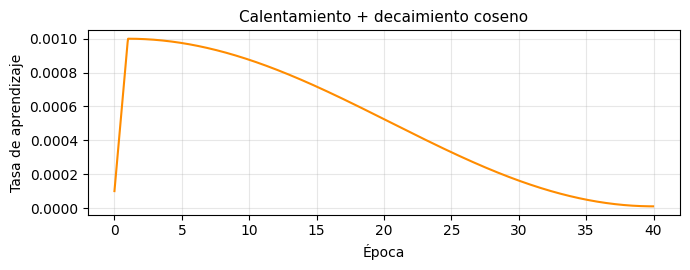

In [14]:
import math
import shutil

PASOS_POR_EPOCA = math.ceil(len(rutas_ent) / TAM_LOTE)

# Calentamiento de 1e-4 a 1e-3 durante la primera época y decaimiento coseno hasta 1e-5 en la última
tasa_aprendizaje = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    warmup_target=1e-3,
    warmup_steps=PASOS_POR_EPOCA,
    decay_steps=(EPOCAS_MAX - 1) * PASOS_POR_EPOCA,
    alpha=0.01,
)

modelo.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=tasa_aprendizaje, weight_decay=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Curva de la tasa de aprendizaje que seguirá el entrenamiento
pasos = np.arange(0, EPOCAS_MAX * PASOS_POR_EPOCA, 20)
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.plot(pasos / PASOS_POR_EPOCA, [float(tasa_aprendizaje(p)) for p in pasos], color="darkorange")
ax.set_xlabel("Época")
ax.set_ylabel("Tasa de aprendizaje")
ax.set_title("Calentamiento + decaimiento coseno")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


class TiempoPorEpoca(keras.callbacks.Callback):
    # Agrega a los registros de cada época su duración y la tasa de aprendizaje vigente
    def on_epoch_begin(self, epoch, logs=None):
        self.inicio = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs["segundos"] = time.time() - self.inicio
        logs["learning_rate"] = float(keras.ops.convert_to_numpy(self.model.optimizer.learning_rate))

## 7. Entrenamiento (reanudable)

En cada época la red recorre las ~18,300 imágenes de entrenamiento en lotes de 32 (573 pasos). Para cada lote:

1. **Propagación hacia adelante:** se aplican el aumento de datos y todas las capas, y se obtienen las probabilidades.
2. Se calcula la **pérdida** (entropía cruzada ponderada por el peso de la clase).
3. **Retropropagación:** se obtiene el gradiente de la pérdida respecto a cada uno de los ~2.4 millones de parámetros.
4. **AdamW** actualiza los pesos.

Al final de cada época se mide la pérdida y la exactitud en validación.

### Cómo pausar y reanudar

Entrenar en CPU toma varias horas, así que la celda siguiente está preparada para hacerse **en varias sesiones**:

- **Para pausar:** detener la celda (botón *Interrupt* o apagar la computadora). Se pierde como máximo la época en curso.
- **Para reanudar:** volver a ejecutar el cuaderno desde el inicio. La celda de entrenamiento encuentra el respaldo en `modelos/respaldo_cnn/` y continúa desde la última época completa, con los mismos pesos, el mismo estado del optimizador y el mismo punto de la curva de tasa de aprendizaje.
- **Cuando termina:** el respaldo se borra y queda el modelo final en `modelos/cnn_animals10.keras`. Si se vuelve a ejecutar el cuaderno, **el entrenamiento se omite** y se carga el modelo guardado. Para entrenar de nuevo desde cero, cambiar `FORZAR_ENTRENAMIENTO = True`.

Al reanudar, la paciencia de `EarlyStopping` empieza de nuevo. El mejor valor de validación sí se conserva, porque se lee del historial.

> **Nota de rendimiento:** en esta computadora, la misma red entrenó unas **2.5 veces más rápido** ejecutando el cuaderno desde la terminal que dentro del kernel interactivo de VS Code:
> `python -m jupyter nbconvert --to notebook --execute --inplace --ExecutePreprocessor.timeout=-1 <archivo>.ipynb`

In [15]:
RUTA_MODELOS = Path("modelos")
RUTA_MODELOS.mkdir(exist_ok=True)
RUTA_MODELO = RUTA_MODELOS / "cnn_animals10.keras"      # Mejor modelo (menor pérdida de validación)
RUTA_HISTORIAL = RUTA_MODELOS / "historial_cnn.csv"      # Métricas de todas las épocas
RUTA_RESPALDO = RUTA_MODELOS / "respaldo_cnn"            # Punto de reanudación (se borra al terminar)

FORZAR_ENTRENAMIENTO = False   # True = borrar lo anterior y entrenar desde cero

terminado = RUTA_MODELO.exists() and RUTA_HISTORIAL.exists() and not RUTA_RESPALDO.exists()
hay_respaldo = RUTA_RESPALDO.exists()

if FORZAR_ENTRENAMIENTO or not (terminado or hay_respaldo):
    # Entrenamiento nuevo: se eliminan restos de ejecuciones anteriores
    shutil.rmtree(RUTA_RESPALDO, ignore_errors=True)
    RUTA_MODELO.unlink(missing_ok=True)
    RUTA_HISTORIAL.unlink(missing_ok=True)
    terminado = hay_respaldo = False

if terminado:
    print("El modelo ya está entrenado: se carga desde disco y se omite el entrenamiento.")
else:
    print("Se encontró un respaldo: el entrenamiento continúa desde la última época completa."
          if hay_respaldo else "Entrenamiento nuevo.")

    # Si se reanuda, el mejor val_loss previo evita que ModelCheckpoint guarde un modelo peor
    mejor_previo = pd.read_csv(RUTA_HISTORIAL)["val_loss"].min() if RUTA_HISTORIAL.exists() else None

    callbacks = [
        TiempoPorEpoca(),
        keras.callbacks.ModelCheckpoint(RUTA_MODELO, monitor="val_loss", save_best_only=True,
                                        initial_value_threshold=mejor_previo),
        keras.callbacks.CSVLogger(RUTA_HISTORIAL, append=True),
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, verbose=1),
        keras.callbacks.BackupAndRestore(RUTA_RESPALDO),   # Va al final: respalda cuando todo lo demás ya se guardó
    ]
    modelo.fit(
        ds_ent,
        validation_data=ds_val,
        epochs=EPOCAS_MAX,
        class_weight=PESOS_CLASE,
        callbacks=callbacks,
        verbose=2,            # Una línea por época
    )

# Mejor modelo guardado por ModelCheckpoint
modelo = keras.models.load_model(RUTA_MODELO)

# Historial completo de todas las sesiones (si una época se repitió al reanudar, se queda la última)
historial = (pd.read_csv(RUTA_HISTORIAL).drop_duplicates("epoch", keep="last")
             .sort_values("epoch").reset_index(drop=True))
historial["epoch"] += 1
mejor = historial.loc[historial["val_loss"].idxmin()]
mejor_epoca = int(mejor["epoch"])
duracion_cnn = historial["segundos"].sum()

print(f"\nÉpocas entrenadas: {len(historial)}. Mejor época (menor val_loss): {mejor_epoca}")
print(f"Exactitud en validación de la mejor época: {mejor['val_accuracy']:.2%}")
print(f"Tiempo total de entrenamiento: {duracion_cnn / 3600:.2f} h "
      f"({historial['segundos'].median() / 60:.1f} min por época, mediana)")

Se encontró un respaldo: el entrenamiento continúa desde la última época completa.
Epoch 4/40


573/573 - 311s - 543ms/step - accuracy: 0.6280 - loss: 1.0936 - val_accuracy: 0.2378 - val_loss: 3.0380 - segundos: 310.6581 - learning_rate: 9.8562e-04


Epoch 5/40


573/573 - 384s - 671ms/step - accuracy: 0.6642 - loss: 0.9877 - val_accuracy: 0.3221 - val_loss: 2.7895 - segundos: 384.1620 - learning_rate: 9.7453e-04


Epoch 6/40


...

Epoch 39/40


573/573 - 268s - 468ms/step - accuracy: 0.9800 - loss: 0.0612 - val_accuracy: 0.8699 - val_loss: 0.5063 - segundos: 267.8825 - learning_rate: 1.1605e-05


Epoch 40/40


573/573 - 271s - 473ms/step - accuracy: 0.9806 - loss: 0.0573 - val_accuracy: 0.8734 - val_loss: 0.4909 - segundos: 270.9164 - learning_rate: 1.0000e-05



Épocas entrenadas: 40. Mejor época (menor val_loss): 37
Exactitud en validación de la mejor época: 87.68%
Tiempo total de entrenamiento: 3.60 h (4.7 min por época, mediana)


## 8. Evaluación de la CNN

### 8.1 Curvas de aprendizaje

Se construyen a partir del historial en CSV, así que incluyen todas las épocas aunque el entrenamiento se haya hecho en varias sesiones.

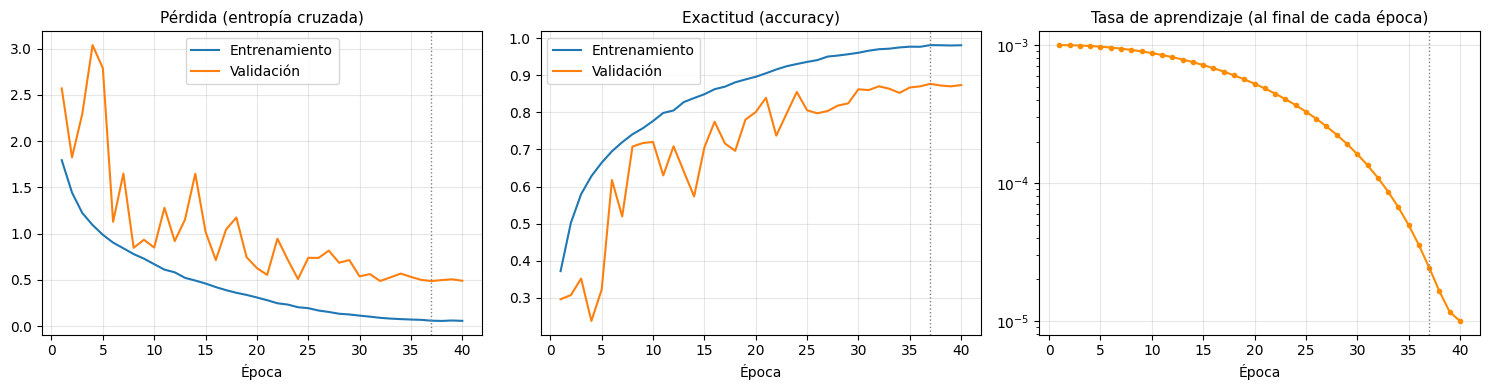

 epoch   loss  accuracy  val_loss  val_accuracy
    36 0.0681    0.9765    0.5001        0.8699
    37 0.0591    0.9810    0.4876        0.8768
    38 0.0564    0.9807    0.4983        0.8722
    39 0.0612    0.9800    0.5063        0.8699
    40 0.0573    0.9806    0.4909        0.8734


In [16]:
h = historial
fig, ejes = plt.subplots(1, 3, figsize=(15, 4))
ejes[0].plot(h["epoch"], h["loss"], label="Entrenamiento")
ejes[0].plot(h["epoch"], h["val_loss"], label="Validación")
ejes[0].set_title("Pérdida (entropía cruzada)")
ejes[1].plot(h["epoch"], h["accuracy"], label="Entrenamiento")
ejes[1].plot(h["epoch"], h["val_accuracy"], label="Validación")
ejes[1].set_title("Exactitud (accuracy)")
ejes[2].plot(h["epoch"], h["learning_rate"], color="darkorange", marker="o", ms=3)
ejes[2].set_yscale("log")
ejes[2].set_title("Tasa de aprendizaje (al final de cada época)")
for ax in ejes:
    ax.axvline(mejor_epoca, color="gray", ls=":", lw=1)
    ax.set_xlabel("Época")
    ax.grid(alpha=0.3)
ejes[0].legend()
ejes[1].legend()
plt.tight_layout()
plt.show()

print(h[["epoch", "loss", "accuracy", "val_loss", "val_accuracy"]].tail(5).round(4).to_string(index=False))

### 8.2 Desempeño en el conjunto de prueba

Estas son las imágenes que la red **nunca vio** durante el entrenamiento ni en la selección del modelo.

In [17]:
perdida_pru, exactitud_pru = modelo.evaluate(ds_pru, verbose=0)
print(f"Pérdida en prueba  : {perdida_pru:.4f}")
print(f"Exactitud en prueba: {exactitud_pru:.2%}")

# Probabilidades y clase predicha para cada imagen de prueba (ds_pru no está barajado)
probas_pru = modelo.predict(ds_pru, verbose=0)
pred_pru = probas_pru.argmax(axis=1)


def exactitud_top2(y, probas):
    # Proporción de imágenes cuya clase correcta está entre las 2 más probables
    return np.mean((np.argsort(probas, axis=1)[:, -2:] == y[:, None]).any(axis=1))


print(f"Exactitud top-2    : {exactitud_top2(y_pru, probas_pru):.2%}")
print(f"Referencia al azar : {1 / NUM_CLASES:.0%} (o {np.bincount(y_pru).max() / len(y_pru):.1%} si siempre se predice la clase mayoritaria)\n")

print(classification_report(y_pru, pred_pru, target_names=CLASES, digits=3, zero_division=0))

Pérdida en prueba  : 0.4130
Exactitud en prueba: 88.74%


Exactitud top-2    : 95.34%
Referencia al azar : 10% (o 18.6% si siempre se predice la clase mayoritaria)

              precision    recall  f1-score   support

       perro      0.918     0.845     0.880       730
     caballo      0.876     0.898     0.887       393
    elefante      0.913     0.866     0.889       217
    mariposa      0.821     0.953     0.882       317
     gallina      0.896     0.946     0.921       465
        gato      0.947     0.784     0.858       250
        vaca      0.839     0.839     0.839       280
       oveja      0.765     0.883     0.820       273
       araña      0.942     0.923     0.932       723
     ardilla      0.888     0.882     0.885       279

    accuracy                          0.887      3927
   macro avg      0.880     0.882     0.879      3927
weighted avg      0.891     0.887     0.888      3927



**Cómo leer el reporte:**

- **Precisión (*precision*):** de las imágenes que la red etiquetó como una especie, qué porcentaje realmente lo era.
- **Sensibilidad (*recall*):** de las imágenes de una especie, qué porcentaje encontró la red.
- **F1:** media armónica de las dos anteriores.
- **Macro avg:** promedio simple entre clases; cada especie cuenta igual sin importar cuántas imágenes tenga.

### 8.3 Matriz de confusión

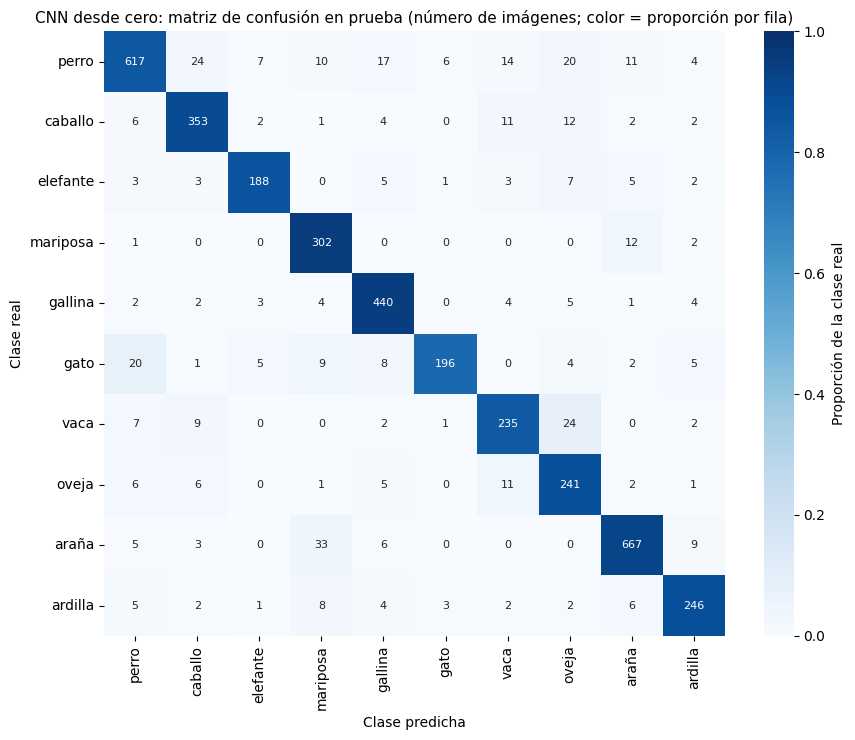

Confusiones más frecuentes (real -> predicha):
      araña -> mariposa : 33 imágenes
       vaca -> oveja    : 24 imágenes
      perro -> caballo  : 24 imágenes
      perro -> oveja    : 20 imágenes
       gato -> perro    : 20 imágenes
      perro -> gallina  : 17 imágenes


In [18]:
def graficar_confusion(y_real, y_pred, titulo):
    matriz = confusion_matrix(y_real, y_pred)
    matriz_norm = matriz / matriz.sum(axis=1, keepdims=True)   # Cada fila suma 1 (recall por clase)

    fig, ax = plt.subplots(figsize=(9, 7.5))
    sns.heatmap(matriz_norm, annot=matriz, fmt="d", cmap="Blues", vmin=0, vmax=1,
                cbar_kws={"label": "Proporción de la clase real"},
                xticklabels=CLASES, yticklabels=CLASES, ax=ax, annot_kws={"fontsize": 8})
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

    # Pares de clases que más se confunden
    confusiones = [(matriz[i, j], CLASES[i], CLASES[j]) for i in range(NUM_CLASES)
                   for j in range(NUM_CLASES) if i != j]
    print("Confusiones más frecuentes (real -> predicha):")
    for n, real, pred in sorted(confusiones, reverse=True)[:6]:
        print(f"  {real:>9s} -> {pred:<9s}: {n} imágenes")


graficar_confusion(y_pru, pred_pru, "CNN desde cero: matriz de confusión en prueba (número de imágenes; color = proporción por fila)")

### 8.4 Ejemplos de predicciones

Imágenes de prueba al azar. En verde, las que la red clasificó bien; en rojo, las que no. Se muestra la probabilidad que asignó a su predicción.

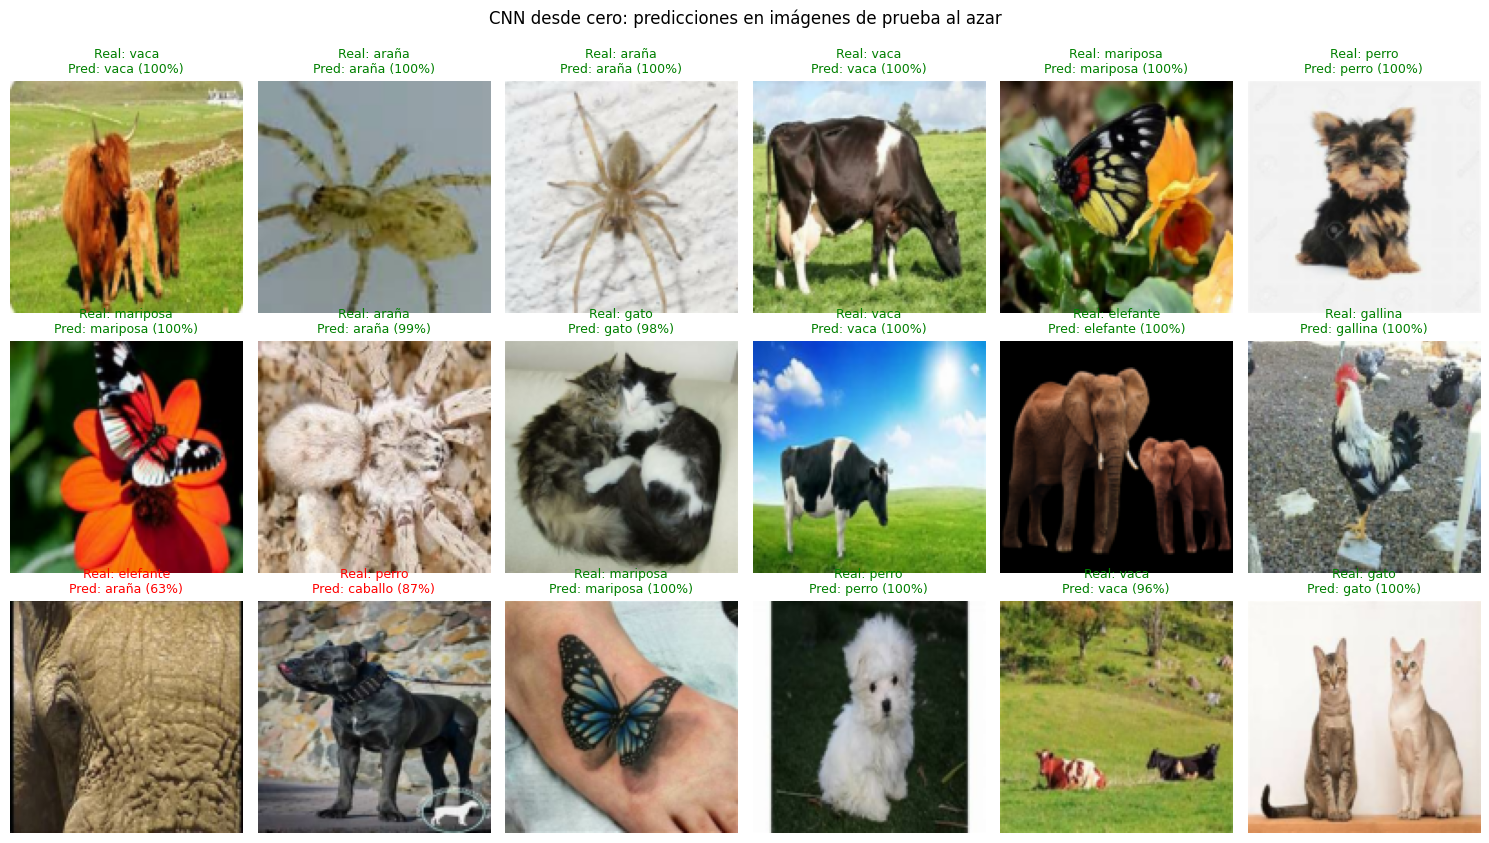

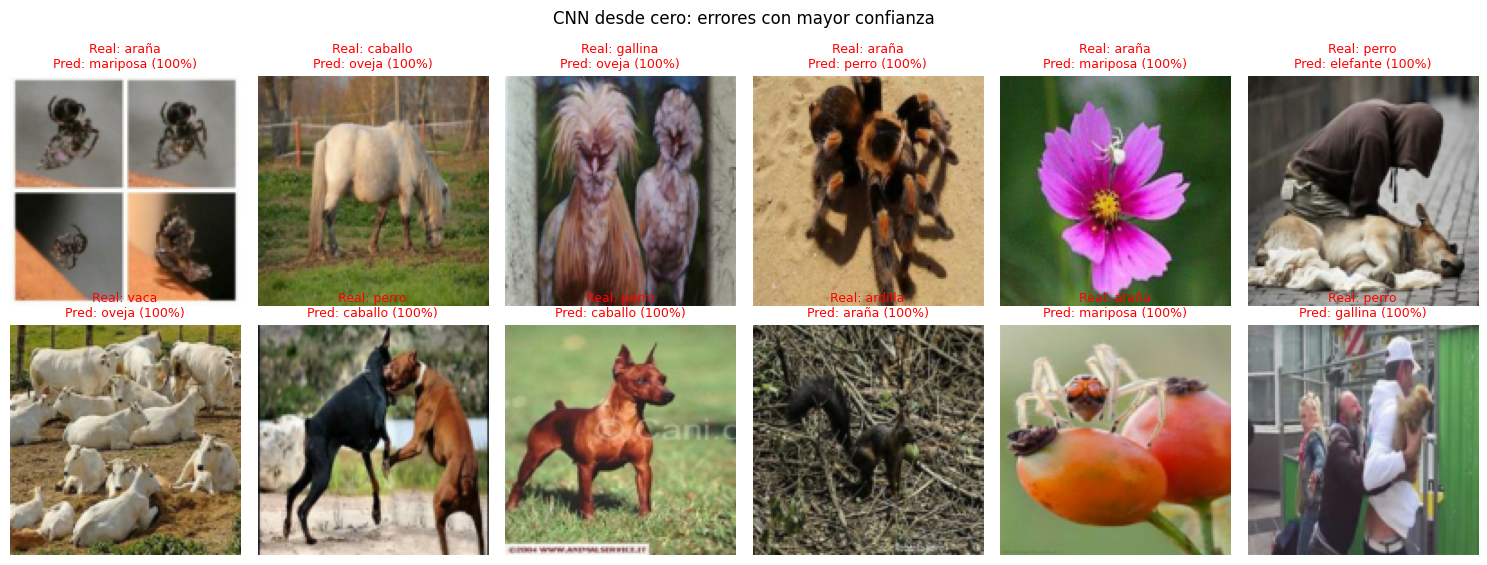

In [19]:
def mostrar_predicciones(indices, titulo, probas, columnas=6):
    preds = probas.argmax(axis=1)
    filas = int(np.ceil(len(indices) / columnas))
    fig, ejes = plt.subplots(filas, columnas, figsize=(2.5 * columnas, 2.8 * filas))
    for ax, i in zip(np.ravel(ejes), indices):
        imagen, _ = cargar_imagen(rutas_pru[i], y_pru[i])
        ax.imshow(imagen.numpy())
        ax.set_title(f"Real: {CLASES[y_pru[i]]}\nPred: {CLASES[preds[i]]} ({probas[i].max():.0%})",
                     color="green" if preds[i] == y_pru[i] else "red", fontsize=9)
    for ax in np.ravel(ejes):
        ax.axis("off")
    plt.suptitle(titulo, y=1.0)
    plt.tight_layout()
    plt.show()


rng = np.random.default_rng(SEMILLA)
indices_ejemplo = rng.choice(len(y_pru), 18, replace=False)
mostrar_predicciones(indices_ejemplo, "CNN desde cero: predicciones en imágenes de prueba al azar", probas_pru)

# Errores en los que la red estaba más segura de sí misma
errores = np.where(pred_pru != y_pru)[0]
errores = errores[np.argsort(-probas_pru[errores].max(axis=1))][:12]
mostrar_predicciones(errores, "CNN desde cero: errores con mayor confianza", probas_pru)

### 8.5 ¿Qué ve la red? Mapas de características

Para entender qué aprendió el extractor, se muestra lo que producen algunos filtros del **primer** y del **cuarto** bloque para una imagen de prueba. En el bloque 1 los mapas todavía se parecen a la imagen: resaltan bordes, contornos y zonas de color. En el bloque 4 ya son abstractos y de baja resolución (16×16): cada uno se activa donde encuentra un patrón más complejo.

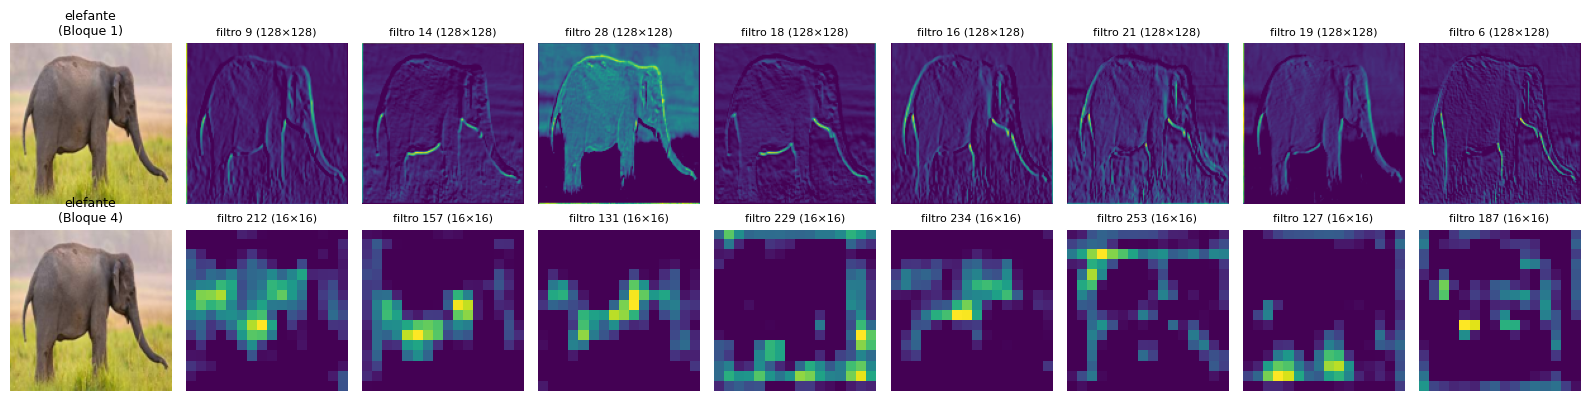

In [20]:
extractor = keras.Model(modelo.input, [modelo.get_layer("relu1_1").output, modelo.get_layer("relu4_2").output])
imagen_ej, etiqueta_ej = cargar_imagen(rutas_pru[0], y_pru[0])
mapas_b1, mapas_b4 = extractor(tf.cast(imagen_ej, tf.float32)[None], training=False)

fig, ejes = plt.subplots(2, 9, figsize=(16, 4))
for fila, (mapas, nombre) in enumerate([(mapas_b1, "Bloque 1"), (mapas_b4, "Bloque 4")]):
    mapas = keras.ops.convert_to_numpy(mapas)
    ejes[fila, 0].imshow(imagen_ej.numpy())
    ejes[fila, 0].set_title(f"{CLASES[etiqueta_ej]}\n({nombre})", fontsize=9)
    # Los 8 filtros con mayor activación promedio para esta imagen
    mejores = np.argsort(-mapas[0].mean(axis=(0, 1)))[:8]
    for k, f in enumerate(mejores, start=1):
        ejes[fila, k].imshow(mapas[0, :, :, f], cmap="viridis")
        ejes[fila, k].set_title(f"filtro {f} ({mapas.shape[1]}×{mapas.shape[2]})", fontsize=8)
for ax in np.ravel(ejes):
    ax.axis("off")
plt.tight_layout()
plt.show()

## 9. Comparación: transfer learning con EfficientNetB0

Como punto de referencia, se entrena el **mismo tipo de clasificador** (capa densa + softmax), pero ahora sobre las características de una red **preentrenada** en ImageNet, en lugar de sobre las de la CNN diseñada desde cero.

### 9.1 Idea

**Transfer learning** consiste en reutilizar una red que ya aprendió a "ver" en un problema grande. EfficientNetB0 (Tan & Le, 2019) se entrenó con **1.28 millones de imágenes de 1000 categorías** de ImageNet, entre las que hay muchos animales. Sus capas convolucionales ya saben detectar bordes, texturas, ojos, patas, pelaje y plumas. Se aprovecha así:

1. Se quita la capa de salida original (las 1000 clases de ImageNet) y se **congelan** todos sus pesos.
2. Cada imagen pasa **una sola vez** por la red y se guarda su vector de **1280 características** (salida del *global average pooling*). Esto toma unos minutos y se guarda en disco (`modelos/`), así que no se repite.
3. Sobre esos vectores se entrena solo un clasificador pequeño: `Dropout(0.3) → Dense(10, softmax)`, con 12,810 parámetros. Toma segundos.

EfficientNetB0 trabaja con imágenes de **224 × 224**, su resolución original, y trae su propia normalización interna, así que recibe los píxeles en [0, 255]. No se usa aumento de datos porque las características se calculan una sola vez.

In [21]:
TAM_TL = 224
RUTA_CARACT = RUTA_MODELOS / "caracteristicas_efficientnetb0.npz"

base_tl = keras.applications.EfficientNetB0(include_top=False, weights="imagenet",
                                            input_shape=(TAM_TL, TAM_TL, 3), pooling="avg")
base_tl.trainable = False
print(f"EfficientNetB0 sin su capa de salida: {base_tl.count_params():,} parámetros (congelados)")
print(f"Tamaño del vector de características: {base_tl.output_shape[-1]}")


def cargar_imagen_tl(ruta, etiqueta):
    # Igual que cargar_imagen, pero a 224 x 224 y en float32 (EfficientNet normaliza internamente)
    imagen = tf.io.decode_image(tf.io.read_file(ruta), channels=3, expand_animations=False)
    imagen = tf.image.resize(imagen, (TAM_TL, TAM_TL), antialias=True)
    return tf.clip_by_value(imagen, 0, 255), etiqueta


def extraer_caracteristicas(rutas_sub, y_sub):
    ds = (tf.data.Dataset.from_tensor_slices((rutas_sub, y_sub))
          .map(cargar_imagen_tl, num_parallel_calls=AUTOTUNE).batch(64).prefetch(AUTOTUNE))
    return base_tl.predict(ds, verbose=0)


if RUTA_CARACT.exists():
    datos = np.load(RUTA_CARACT)
    F_ent, F_val, F_pru = datos["F_ent"], datos["F_val"], datos["F_pru"]
    duracion_extraccion = float(datos["segundos"])
    print("Características cargadas desde disco.")
else:
    inicio = time.time()
    F_ent = extraer_caracteristicas(rutas_ent, y_ent)
    F_val = extraer_caracteristicas(rutas_val, y_val)
    F_pru = extraer_caracteristicas(rutas_pru, y_pru)
    duracion_extraccion = time.time() - inicio
    np.savez(RUTA_CARACT, F_ent=F_ent, F_val=F_val, F_pru=F_pru, segundos=duracion_extraccion)
    print("Características calculadas y guardadas en disco.")

print(f"Tiempo de extracción: {duracion_extraccion / 60:.1f} min")
print(f"Formas: entrenamiento {F_ent.shape}, validación {F_val.shape}, prueba {F_pru.shape}")

EfficientNetB0 sin su capa de salida: 4,049,571 parámetros (congelados)
Tamaño del vector de características: 1280


Características calculadas y guardadas en disco.
Tiempo de extracción: 4.3 min
Formas: entrenamiento (18325, 1280), validación (3927, 1280), prueba (3927, 1280)


### 9.2 Entrenamiento del clasificador

Model: "clasificador_EfficientNetB0"
+---------------------------------+------------------------+---------------+
| Layer (type)                    | Output Shape           |       Param # |
+---------------------------------+------------------------+---------------+
| dropout (Dropout)               | (None, 1280)           |             0 |
+---------------------------------+------------------------+---------------+
| salida (Dense)                  | (None, 10)             |        12,810 |
+---------------------------------+------------------------+---------------+
 Total params: 12,810 (50.04 KB)
 Trainable params: 12,810 (50.04 KB)
 Non-trainable params: 0 (0.00 B)



Épocas: 16, tiempo: 7 s
Mejor exactitud en validación: 98.04%


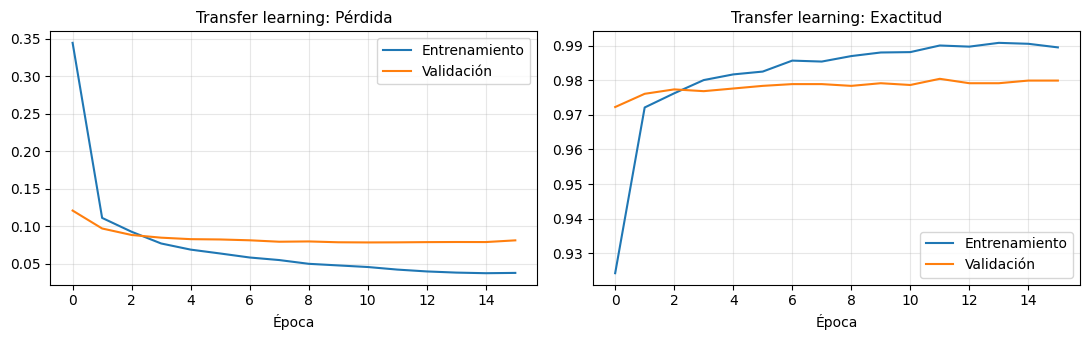

In [22]:
keras.utils.set_random_seed(SEMILLA)
clasificador_tl = keras.Sequential([
    keras.Input(shape=(F_ent.shape[1],), name="caracteristicas"),
    layers.Dropout(0.3, name="dropout"),
    layers.Dense(NUM_CLASES, activation="softmax", name="salida"),
], name="clasificador_EfficientNetB0")
clasificador_tl.compile(optimizer=keras.optimizers.Adam(1e-3),
                        loss="sparse_categorical_crossentropy", metrics=["accuracy"])
clasificador_tl.summary(print_fn=imprimir_resumen)

inicio = time.time()
historial_tl = clasificador_tl.fit(
    F_ent, y_ent, validation_data=(F_val, y_val),
    epochs=50, batch_size=64, class_weight=PESOS_CLASE, verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
)
duracion_tl = time.time() - inicio

h_tl = historial_tl.history
print(f"Épocas: {len(h_tl['loss'])}, tiempo: {duracion_tl:.0f} s")
print(f"Mejor exactitud en validación: {max(h_tl['val_accuracy']):.2%}")

fig, ejes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, met, titulo in [(ejes[0], "loss", "Pérdida"), (ejes[1], "accuracy", "Exactitud")]:
    ax.plot(h_tl[met], label="Entrenamiento")
    ax.plot(h_tl[f"val_{met}"], label="Validación")
    ax.set_title(f"Transfer learning: {titulo}")
    ax.set_xlabel("Época")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

### 9.3 Evaluación en prueba

Se evalúa con las mismas 3,927 imágenes de prueba que la CNN. Además, la red preentrenada y el clasificador se unen en un **modelo completo** que recibe una imagen cruda de 224 × 224 y devuelve las 10 probabilidades. Ese modelo se guarda en `modelos/efficientnetb0_animals10.keras`.

In [23]:
probas_tl = clasificador_tl.predict(F_pru, verbose=0)
pred_tl = probas_tl.argmax(axis=1)
exactitud_tl = np.mean(pred_tl == y_pru)

print(f"Exactitud en prueba: {exactitud_tl:.2%}")
print(f"Exactitud top-2    : {exactitud_top2(y_pru, probas_tl):.2%}\n")
print(classification_report(y_pru, pred_tl, target_names=CLASES, digits=3, zero_division=0))

# Modelo completo: imagen (224x224x3, valores 0-255) -> EfficientNetB0 congelada -> clasificador
modelo_tl = keras.Sequential([keras.Input(shape=(TAM_TL, TAM_TL, 3), name="imagen"), base_tl, clasificador_tl],
                             name="EfficientNetB0_Animals10")
modelo_tl.save(RUTA_MODELOS / "efficientnetb0_animals10.keras")

Exactitud en prueba: 97.91%
Exactitud top-2    : 99.31%

              precision    recall  f1-score   support

       perro      0.973     0.979     0.976       730
     caballo      0.977     0.969     0.973       393
    elefante      0.986     0.972     0.979       217
    mariposa      0.978     0.994     0.986       317
     gallina      0.993     0.981     0.987       465
        gato      0.969     0.984     0.976       250
        vaca      0.950     0.950     0.950       280
       oveja      0.956     0.960     0.958       273
       araña      0.999     0.992     0.995       723
     ardilla      0.982     0.989     0.986       279

    accuracy                          0.979      3927
   macro avg      0.976     0.977     0.977      3927
weighted avg      0.979     0.979     0.979      3927



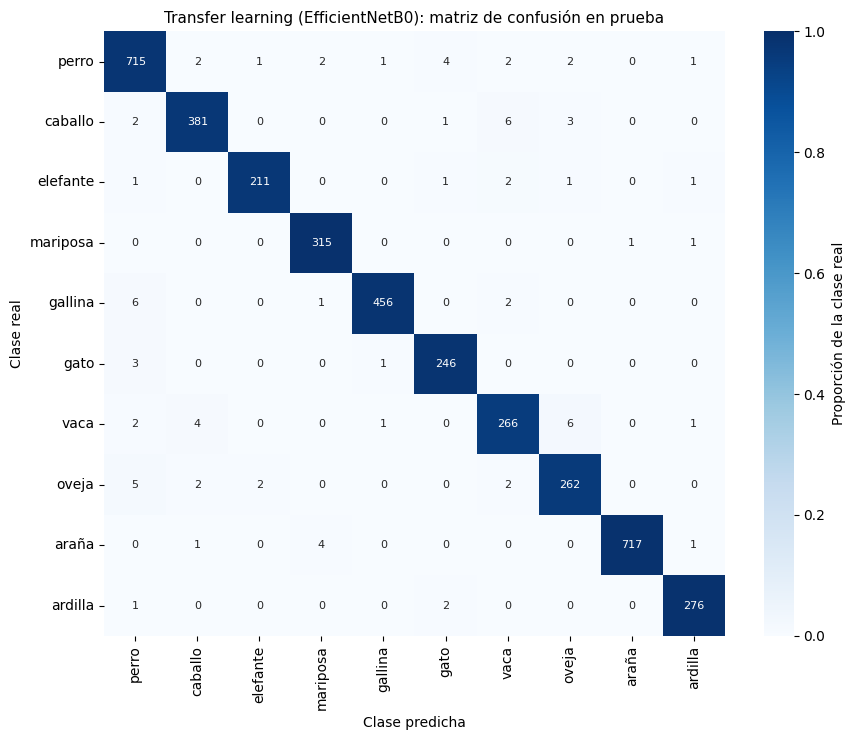

Confusiones más frecuentes (real -> predicha):
       vaca -> oveja    : 6 imágenes
    gallina -> perro    : 6 imágenes
    caballo -> vaca     : 6 imágenes
      oveja -> perro    : 5 imágenes
       vaca -> caballo  : 4 imágenes
      perro -> gato     : 4 imágenes


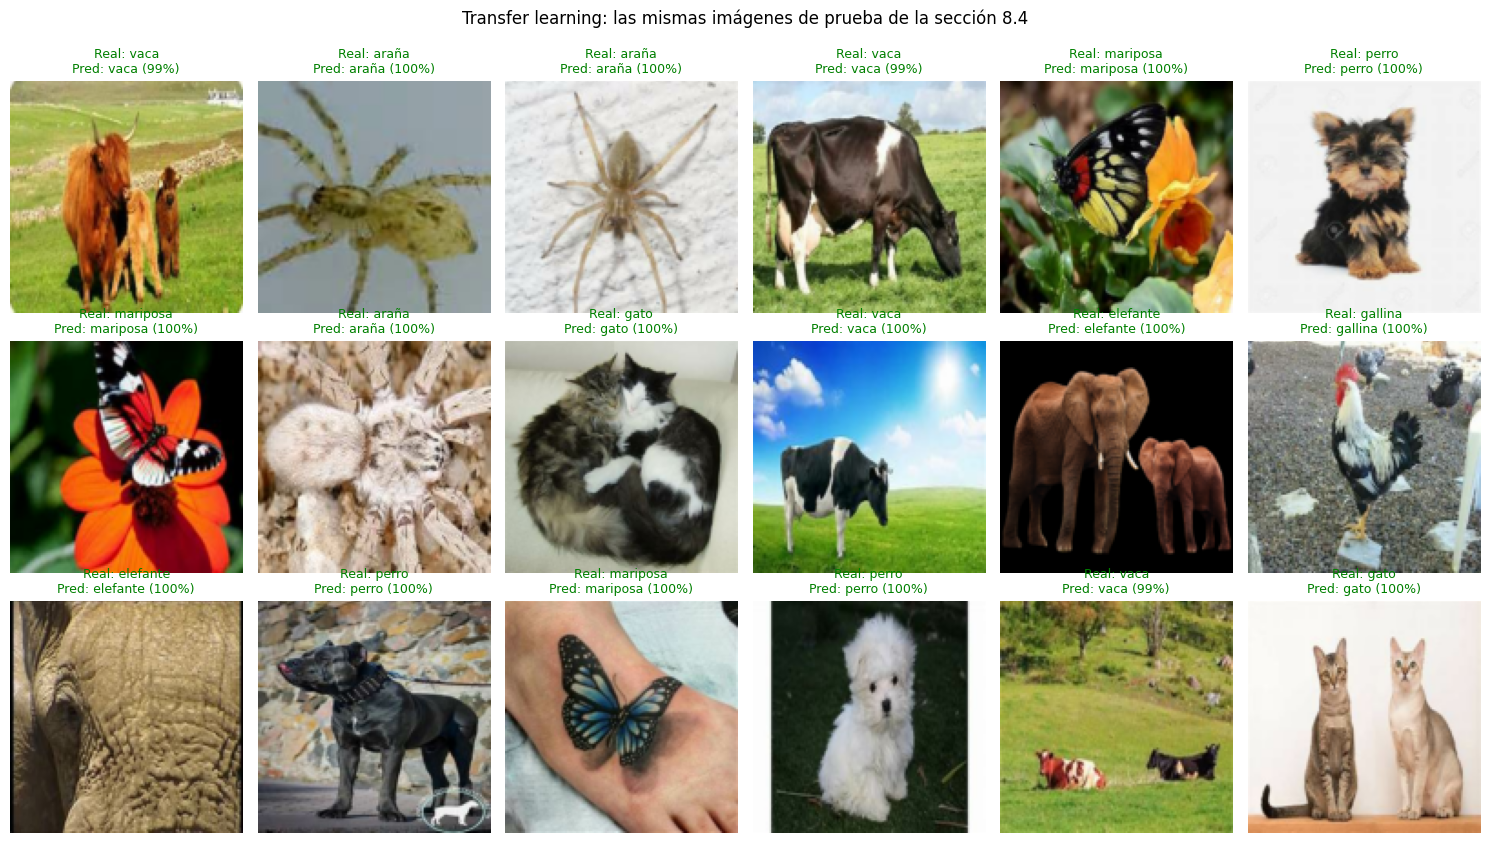

In [24]:
graficar_confusion(y_pru, pred_tl, "Transfer learning (EfficientNetB0): matriz de confusión en prueba")
mostrar_predicciones(indices_ejemplo, "Transfer learning: las mismas imágenes de prueba de la sección 8.4", probas_tl)

### 9.4 Comparación de los modelos

                       Modelo Parámetros entrenables Exactitud prueba F1 macro           Tiempo de entrenamiento
            CNN desde cero v1                423,082           59.49%    0.581     7.5 h (35 épocas, en VS Code)
            CNN desde cero v2              2,441,514           88.74%    0.879                 3.6 h (40 épocas)
EfficientNetB0 + clasificador                 12,810           97.91%    0.977 4 min (extracción + clasificador)


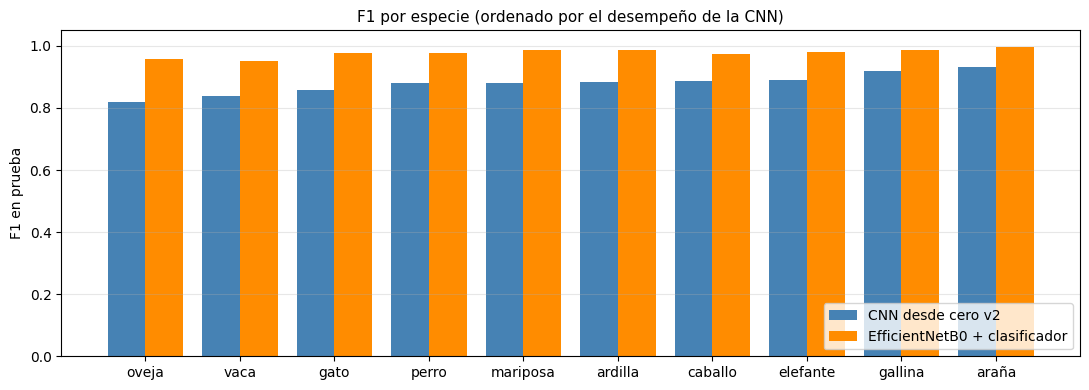

In [25]:
from sklearn.metrics import f1_score

# La versión 1 de la CNN se entrenó en una ejecución anterior (ver sección 5.1); sus valores se registran aquí
comparacion = pd.DataFrame([
    {"Modelo": "CNN desde cero v1", "Parámetros entrenables": 423_082, "Exactitud prueba": 0.5949,
     "F1 macro": 0.581, "Tiempo de entrenamiento": "7.5 h (35 épocas, en VS Code)"},
    {"Modelo": "CNN desde cero v2",
     "Parámetros entrenables": int(sum(np.prod(w.shape) for w in modelo.trainable_weights)),
     "Exactitud prueba": exactitud_pru, "F1 macro": f1_score(y_pru, pred_pru, average="macro"),
     "Tiempo de entrenamiento": f"{duracion_cnn / 3600:.1f} h ({len(historial)} épocas)"},
    {"Modelo": "EfficientNetB0 + clasificador", "Parámetros entrenables": clasificador_tl.count_params(),
     "Exactitud prueba": exactitud_tl, "F1 macro": f1_score(y_pru, pred_tl, average="macro"),
     "Tiempo de entrenamiento": f"{(duracion_extraccion + duracion_tl) / 60:.0f} min (extracción + clasificador)"},
])
print(comparacion.to_string(index=False, formatters={
    "Parámetros entrenables": "{:,}".format, "Exactitud prueba": "{:.2%}".format, "F1 macro": "{:.3f}".format}))

# F1 por clase: CNN v2 vs transfer learning
f1_cnn = f1_score(y_pru, pred_pru, average=None)
f1_tl = f1_score(y_pru, pred_tl, average=None)
orden = np.argsort(f1_cnn)
x = np.arange(NUM_CLASES)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - 0.2, f1_cnn[orden], 0.4, label="CNN desde cero v2", color="steelblue")
ax.bar(x + 0.2, f1_tl[orden], 0.4, label="EfficientNetB0 + clasificador", color="darkorange")
ax.set_xticks(x, [CLASES[i] for i in orden])
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1 en prueba")
ax.set_title("F1 por especie (ordenado por el desempeño de la CNN)")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Análisis de resultados

### 10.1 Resumen de resultados

| Modelo | Exactitud en prueba | Top-2 | F1 macro | Tiempo de entrenamiento |
|---|---|---|---|---|
| CNN desde cero, versión 1 | 59.49 % | 78.25 % | 0.581 | 7.5 h (35 épocas) |
| **CNN desde cero, versión 2** | **88.74 %** | **95.34 %** | **0.879** | **3.6 h (40 épocas)** |
| EfficientNetB0 + clasificador | 97.91 % | 99.31 % | 0.977 | 4.3 min de extracción + 7 s de entrenamiento |

Las tres cifras se miden sobre las mismas 3,927 imágenes de prueba. La referencia sin aprender nada es 10 % (azar) o 18.6 % (predecir siempre "perro").

### 10.2 CNN desde cero: de la versión 1 a la versión 2

Los cambios de diseño de la sección 5.1 subieron la exactitud **de 59.5 % a 88.7 %** (+29.2 puntos). El diagnóstico de subajuste fue correcto:

- **Capacidad.** La versión 1 no pasó de 67 % en entrenamiento; la versión 2 llegó a 98 %. Con más filtros y un bloque más, la red sí puede representar las diferencias entre especies.
- **Pesos por clase suavizados.** En la versión 1, la sensibilidad del perro era de solo 31 % porque la red "prefería" las clases con peso alto. Con la raíz cuadrada, la sensibilidad del perro subió a 84.5 %. Ahora ninguna clase queda por debajo de 78 % de sensibilidad (la peor es el gato con 78.4 %).
- **Tasa de aprendizaje coseno.** Las curvas de la sección 8.1 muestran dos fases. Hasta la época ~25, con tasa alta, la validación oscila mucho (bajó a 24 % en la época 4 y a 57 % en la 12). A partir de la época 28, cuando la tasa baja de ~0.00016, la validación se estabiliza entre 85 % y 88 % y la pérdida de validación queda plana en ~0.49. El mejor modelo es el de la época 37.
- **Tiempo.** Aunque la red es 5.8 veces más grande, entrenó en la mitad del tiempo. La mejora no vino de la red, sino de ejecutar el cuaderno desde la terminal y de guardar la caché de imágenes en disco en lugar de en RAM.

### 10.3 Fortalezas de la CNN

- **Buen desempeño sin conocimiento previo:** 88.7 % aprendiendo solo de ~18 mil fotografías, con una red de 2.4 millones de parámetros diseñada a mano.
- **Equilibrio entre clases:** F1 macro de 0.879, prácticamente igual a la exactitud. El desbalance del dataset ya no sesga a la red.
- **Cuando se equivoca, suele dudar entre dos:** con 95.3 % de exactitud top-2, la especie correcta casi siempre es la primera o la segunda opción.
- **Mejores clases:** araña (F1 0.932) y gallina (0.921), que tienen formas y texturas muy características.

### 10.4 Limitaciones y errores de la CNN

- **Sobreajuste al final.** Termina con 98 % en entrenamiento y 87–88 % en validación. Esa brecha de 10 puntos indica que, con la regularización reducida, la red empezó a memorizar. La pérdida de validación dejó de bajar, pero no subió, gracias a que la tasa de aprendizaje ya era muy pequeña.
- **Confusiones entre animales parecidos:** vaca → oveja (24 imágenes), perro → caballo (24), perro → oveja (20) y gato → perro (20). Las clases con peor F1 son justamente oveja (0.820) y vaca (0.839): ambas son cuadrúpedos de granja, fotografiados sobre pasto y muchas veces en grupo.
- **Dependencia del contexto.** La confusión más frecuente es araña → mariposa (33 imágenes). En los errores con mayor confianza (sección 8.4) aparecen arañas pequeñas sobre flores: la red asoció "flor" con "mariposa", porque en el dataset casi todas las mariposas están sobre flores. Es un sesgo conocido de las CNN: aprenden correlaciones del fondo, no solo del objeto.
- **Ruido en los datos.** Varios errores "seguros" (100 %) son imágenes difíciles incluso para una persona: collages de varias fotos, un perro casi cubierto por personas, vacas blancas que parecen ovejas. El dataset se descargó de Google Images y trae este tipo de casos.
- **Resolución.** A 128 × 128 se pierden detalles finos (textura del pelaje, forma de las orejas) que ayudarían a separar gato de perro o vaca de oveja.

### 10.5 Transfer learning

EfficientNetB0 con un clasificador de 12,810 parámetros llegó a **97.9 %**, 9.2 puntos arriba de la CNN, en una fracción del tiempo. Todas las especies tienen un F1 de 0.95 o más, y los errores que quedan son los mismos pares de animales de granja (vaca, oveja y caballo), aunque 4 a 6 veces menos frecuentes.

La diferencia no significa que la CNN esté mal diseñada. EfficientNetB0 aprendió sus características con 1.28 millones de imágenes de ImageNet, que incluye cientos de razas de perros, gatos, arañas, aves y animales de granja. La CNN desde cero solo vio 18,325 imágenes. La comparación muestra el **valor de los datos**: una red preentrenada ya trae aprendido lo que a la CNN le cuesta más, reconocer el animal con independencia del fondo. Aun así, la CNN diseñada desde cero cumple el objetivo de la práctica y deja ver cada decisión de diseño; el transfer learning sirve como referencia de lo que se puede alcanzar.

## 11. Justificación del uso de aprendizaje profundo y de la arquitectura

### ¿Por qué aprendizaje profundo?

- **Las características no se pueden definir a mano.** No hay una regla escrita que distinga una vaca de un caballo en cualquier pose, luz, distancia o fondo. Los métodos clásicos (descriptores de color, bordes o texturas + un clasificador) dependen de esas reglas y fallan con fotografías no controladas. Una red profunda **aprende las características directamente de los píxeles**, y lo hace por niveles: bordes, texturas, partes y animales completos. Los mapas de la sección 8.5 muestran esa jerarquía.
- **Hay datos suficientes.** Con ~26 mil imágenes etiquetadas es posible entrenar millones de parámetros sin memorizar el conjunto por completo, sobre todo con aumento de datos.
- **Escala al problema real.** En fototrampeo se generan millones de imágenes; una vez entrenado, el modelo clasifica cada una en milisegundos. Norouzzadeh et al. (2018) mostraron que este enfoque puede automatizar la mayor parte del etiquetado en proyectos reales de conservación.
- **Resultados.** La CNN llegó a 88.7 % y el transfer learning a 97.9 %, frente a 10 % de una clasificación al azar.

### ¿Por qué una red convolucional?

- **Conectividad local.** Los patrones que importan (un ojo, una pata, la textura del pelo) ocupan regiones pequeñas. Cada neurona de una capa convolucional solo mira una ventana de 3×3, y al apilar capas su campo de visión crece hasta cubrir al animal completo.
- **Pesos compartidos.** El mismo filtro recorre toda la imagen, así que un detector de "oreja" sirve en cualquier posición. Esto reduce drásticamente los parámetros: una red totalmente conectada con 256 neuronas sobre una imagen de 128×128×3 necesitaría **12.6 millones de pesos solo en su primera capa**, más de 5 veces la CNN completa.
- **Tolerancia a desplazamientos.** El pooling y el *global average pooling* hacen que la decisión dependa de **qué** patrones hay en la imagen y no de **dónde** están. Un animal puede aparecer en cualquier parte de la foto.
- **Estándar probado.** Las CNN son la arquitectura clásica para clasificar imágenes, desde LeNet (LeCun et al., 1998) hasta las redes modernas como EfficientNet (Tan & Le, 2019).

### ¿Por qué esta arquitectura en particular?

- Filtros que **se duplican mientras la resolución se reduce a la mitad**: mantiene un costo de cómputo parecido en cada bloque y aumenta la capacidad justo donde se combinan patrones más complejos.
- **BatchNormalization** en cada convolución para entrenar una red de 5 bloques de forma estable, y **GlobalAveragePooling** para no disparar los parámetros del clasificador.
- **Tamaño ajustado al hardware:** con entrada de 128×128 y 2.4 millones de parámetros, el entrenamiento cupo en ~3.6 horas de CPU. La primera versión demostró que una red más pequeña se quedaba corta.

## 12. Conclusiones y posibles mejoras

### Conclusiones

1. **Se cumplió el objetivo.** Una CNN diseñada desde cero clasifica fotografías de 10 especies con **88.7 % de exactitud** y un F1 macro de 0.879 en imágenes que nunca vio, frente a 10 % del azar.
2. **Diseñar es iterar.** La primera versión se quedó en 59.5 %. Las curvas de entrenamiento y el reporte por clase permitieron diagnosticar tres problemas (subajuste, sobrecompensación del desbalance y validación inestable) y corregir cada uno con un cambio concreto. El resultado fue una mejora de casi 30 puntos.
3. **La regularización debe ajustarse al diagnóstico.** Agregar dropout y aumento de datos "por si acaso" fue contraproducente en la versión 1. Ahora que la versión 2 muestra una brecha de 10 puntos entre entrenamiento y validación, es cuando sí conviene regularizar más.
4. **La tasa de aprendizaje importa tanto como la arquitectura.** Con decaimiento coseno, la validación pasó de oscilar ±20 puntos a quedar estable en las últimas épocas.
5. **El transfer learning es la opción práctica.** Si el objetivo fuera usar el modelo en un sistema real, EfficientNetB0 preentrenada da 97.9 % en minutos y en CPU. El conocimiento aprendido en millones de imágenes vale más que cualquier ajuste fino de una red pequeña.
6. **Los errores restantes tienen explicación.** La mayoría ocurre entre animales parecidos (vaca, oveja, caballo), en imágenes donde el fondo engaña (araña sobre flor) o en fotos problemáticas del propio dataset.

### Posibles mejoras

- **Para la CNN desde cero:**
  - Más aumento de datos (recortes aleatorios, *mixup* o *cutmix*) ahora que hay sobreajuste.
  - Conexiones residuales (tipo ResNet) para una red más profunda.
  - Entrenar a 160 o 224 px para conservar más detalle.
- **Para el transfer learning:** hacer *fine-tuning*, es decir, descongelar los últimos bloques de EfficientNetB0 y entrenarlos con una tasa de aprendizaje baja. Suele sumar 1 o 2 puntos más.
- **Datos:**
  - Limpiar el dataset: quitar collages, imágenes duplicadas y fotos donde el animal casi no se ve.
  - Agregar ejemplos de arañas y mariposas en otros fondos para reducir el sesgo del contexto.
- **Hardware:** entrenar con la GPU de la computadora (RTX 4050) mediante WSL2. Reduciría el tiempo de horas a minutos y permitiría explorar más configuraciones.
- **Aplicación real:** las cámaras trampa toman muchas fotos nocturnas en infrarrojo, muy distintas a las de este dataset. Para ese uso habría que reentrenar o ajustar el modelo con imágenes del lugar donde se va a usar.

## 13. Referencias

- Corrado, A. (2019). *Animals-10* [Conjunto de datos]. Kaggle. <https://www.kaggle.com/datasets/alessiocorrado99/animals10>
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. <https://www.deeplearningbook.org>
- Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing internal covariate shift. *ICML 2015*.
- Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. *ICLR 2015*.
- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE*, 86(11), 2278–2324.
- Loshchilov, I., & Hutter, F. (2019). Decoupled weight decay regularization. *ICLR 2019*.
- Norouzzadeh, M. S., et al. (2018). Automatically identifying, counting, and describing wild animals in camera-trap images with deep learning. *PNAS*, 115(25), E5716–E5725.
- Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *JMLR*, 15, 1929–1958.
- Tan, M., & Le, Q. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. *ICML 2019*.
- RKCbas. *Maestría en Inteligencia Artificial - Prácticas* [Repositorio de GitHub]. Práctica 2.1, Aprendizaje profundo. <https://github.com/RKCbas/LENGUAJES-DE-CIENCIA-DE-DATOS-B-SICO---PRACTICAS/blob/main/Cuatrimestre%204/8%20-%20Aprendizaje%20profundo/Practica%202.1/Dise%C3%B1o%20e%20implementaci%C3%B3n%20de%20una%20red%20de%20aprendizaje%20profundo.ipynb>